In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[10:56:04] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=309070;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=466622;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

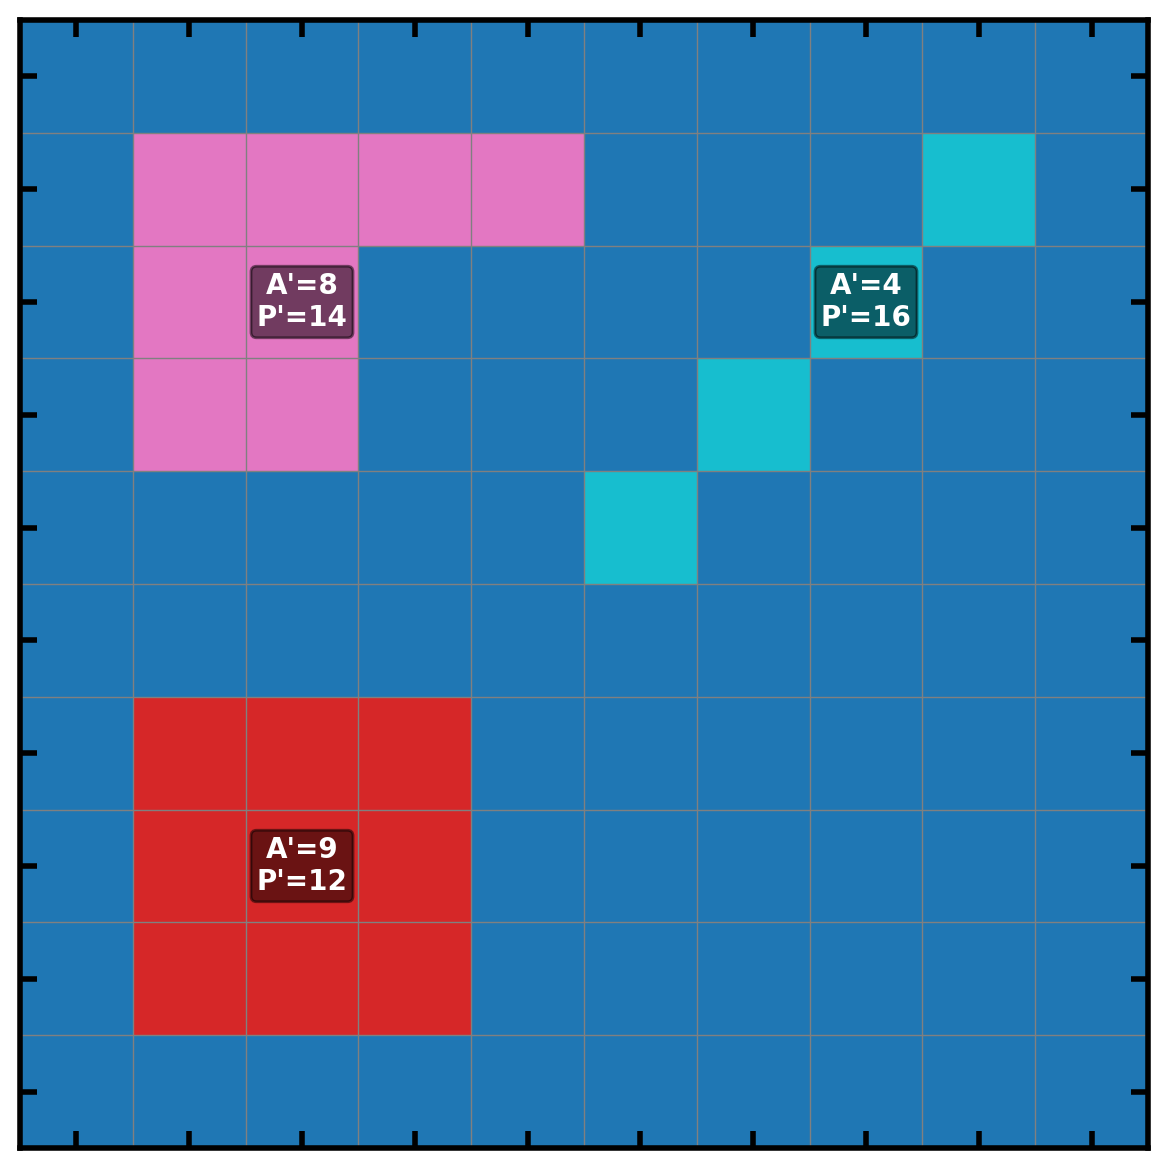

In [9]:
import numpy as np
from matplotlib.patches import Rectangle

import matplotlib.pyplot as plt

# Create a blank grid
grid_size = 10
grid = np.zeros((grid_size, grid_size), dtype=int)

# Draw a few shapes: a square, an L-shape, and a diagonal line
# Square
grid[1:4, 1:4] = 1

# L-shape
grid[6:9, 1:3] = 2
grid[8, 1:5] = 2

# Diagonal line
for i in range(5, 9):
    grid[i, i] = 3

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(grid, cmap='tab10', origin='lower')

# Draw grid lines
for i in range(grid_size + 1):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)
    ax.axvline(i - 0.5, color='gray', linewidth=0.5)

# Annotate area and perimeter for each shape
def count_area_perimeter(mask):
    area = np.sum(mask)
    perimeter = 0
    for x in range(mask.shape[0]):
        for y in range(mask.shape[1]):
            if mask[x, y]:
                # Check 4-neighbors
                for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nx, ny = x+dx, y+dy
                    if nx < 0 or nx >= mask.shape[0] or ny < 0 or ny >= mask.shape[1] or not mask[nx, ny]:
                        perimeter += 1
    return area, perimeter

shapes = {1: "Square", 2: "L-shape", 3: "Diagonal"}
colors = {1: 'black', 2: 'black', 3: 'black'}
positions = {1: (2, 2), 2: (7, 2), 3: (7, 7)}

for val, name in shapes.items():
    mask = (grid == val)
    area, perimeter = count_area_perimeter(mask)
    x, y = positions[val]
    ax.text(y, x, f"A'={area}\nP'={perimeter}", color='white', ha='center', va='center', fontsize=10, fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))

ax.set_xticks(np.arange(grid_size))
ax.set_yticks(np.arange(grid_size))
ax.set_xticklabels([])
ax.set_yticklabels([])
# ax.set_title("Area (A) and Perimeter (P) for Example Shapes", fontsize=14)
plt.tight_layout()
plt.show()

In [2]:
# Q: Can you plot within a single tree a map with a low vs high column density contours?

# Orion A
region_name = "Orion A"

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 8.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down
# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

# Orion B
region_name = "Orion B"

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

2.868994809242656
2.8085460183953956


In [3]:
import scipy.ndimage as ndimage
from skimage.measure import perimeter
import numpy as np

import pickle

def pca_major_axis(region_coords):
    """
    Computes the major axis length of a structure using PCA.
    The major axis is the square root of the largest eigenvalue of the covariance matrix.
    """
    if len(region_coords) < 2:
        return 0  # If only one pixel, size is zero

    # Center the coordinates
    centered_coords = region_coords - np.mean(region_coords, axis=0)

    # Compute covariance matrix and its eigenvalues
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)

    # The largest eigenvalue corresponds to the major axis squared
    major_axis = 2 * np.sqrt(np.max(eigenvalues))  # Factor 2 to approximate full length

    return major_axis

def calculate_mass_and_size(region_mask, M_H2, pc_per_px):
    """
    Calculate the mass and the major axis of a structure using PCA.
    - Mass: Summed pixel values converted to solar masses.
    - Size: Major axis computed from PCA eigenvalues.
    """
    # Compute total mass
    mass = np.sum(M_H2[region_mask])

    # Find structure coordinates
    region_coords = np.column_stack(np.where(region_mask))

    if len(region_coords) == 0:
        return mass, 0  # If no region is found, return zero size

    # Compute the major axis length using PCA
    major_axis_length = pca_major_axis(region_coords)

    # Convert size to parsecs
    size_parsecs = major_axis_length * pc_per_px

    return mass, size_parsecs

def compute_fractal_dimension(region_mask):
    """
    Compute the fractal dimension of a binary region using the Perimeter-Area relation.
    
    Parameters:
        region_mask (ndarray): Boolean mask of the structure.
        
    Returns:
        float: Estimated fractal dimension.
    """
    area = np.sum(region_mask)
    
    # Compute perimeter using dilation technique
    mask_perimeter = perimeter(region_mask)

    if area > 0 and mask_perimeter > 0:
        return 2*(np.log10(mask_perimeter) / np.log10(area))
    return None  # Invalid case (avoid division errors)

def track_largest_regions_NEW(N_H2, M_H2, thresholds, pc_per_px, num_top_regions=None, min_region_size_px=50):
    """
    Extract regions at each threshold and compute their properties.
    """
    regions = {}

    for threshold in thresholds:
        mask = N_H2 >= threshold  
        labeled_regions, num_features = ndimage.label(mask)

        if num_features == 0:
            print(f"[{threshold}] No regions found.")
            continue

        region_sizes = {
            region_id: np.sum(labeled_regions == region_id)
            for region_id in range(1, num_features + 1)
        }

        # Filter by size or pick top N
        region_ids = sorted(region_sizes, key=region_sizes.get, reverse=True)
        if num_top_regions is not None:
            region_ids = region_ids[:num_top_regions]

        saved_count = 0
        for region_id in region_ids:
            size_px = region_sizes[region_id]
            if size_px < min_region_size_px:
                continue

            region_mask = labeled_regions == region_id
            fractal_dim = compute_fractal_dimension(region_mask)
            mass, size = calculate_mass_and_size(region_mask, M_H2, pc_per_px)

            region_key = f"{threshold}_{region_id}"
            regions[region_key] = {
                "threshold": threshold,
                "fractal_dimension": fractal_dim,
                "mass": mass,
                "size": size,
                "region_mask": region_mask
            }
            saved_count += 1

        print(f"[{threshold}] Found {num_features} regions, saved {saved_count}.")

    return regions

[2.4999999999999995e+21] Found 801 regions, saved 20.
[2.5906544706295043e+21] Found 764 regions, saved 20.
[2.6845962344770563e+21] Found 635 regions, saved 20.
[2.781944494673271e+21] Found 630 regions, saved 20.
[2.88282277686738e+21] Found 525 regions, saved 20.
[2.987359085969617e+21] Found 528 regions, saved 20.
[3.095686068577144e+21] Found 472 regions, saved 20.
[3.2079411812899425e+21] Found 448 regions, saved 20.
[3.3242668651301144e+21] Found 457 regions, saved 20.
[3.4448107262859726e+21] Found 407 regions, saved 20.
[3.569725723410091e+21] Found 375 regions, saved 20.
[3.6991703617093994e+21] Found 392 regions, saved 20.
[3.833308894073048e+21] Found 404 regions, saved 20.
[3.972311529493674e+21] Found 358 regions, saved 20.
[4.1163546490463993e+21] Found 333 regions, saved 20.
[4.2656210296994414e+21] Found 324 regions, saved 20.
[4.4203000762408365e+21] Found 275 regions, saved 20.
[4.5805880616149063e+21] Found 274 regions, saved 20.
[4.746688375973919e+21] Found 285 re

c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


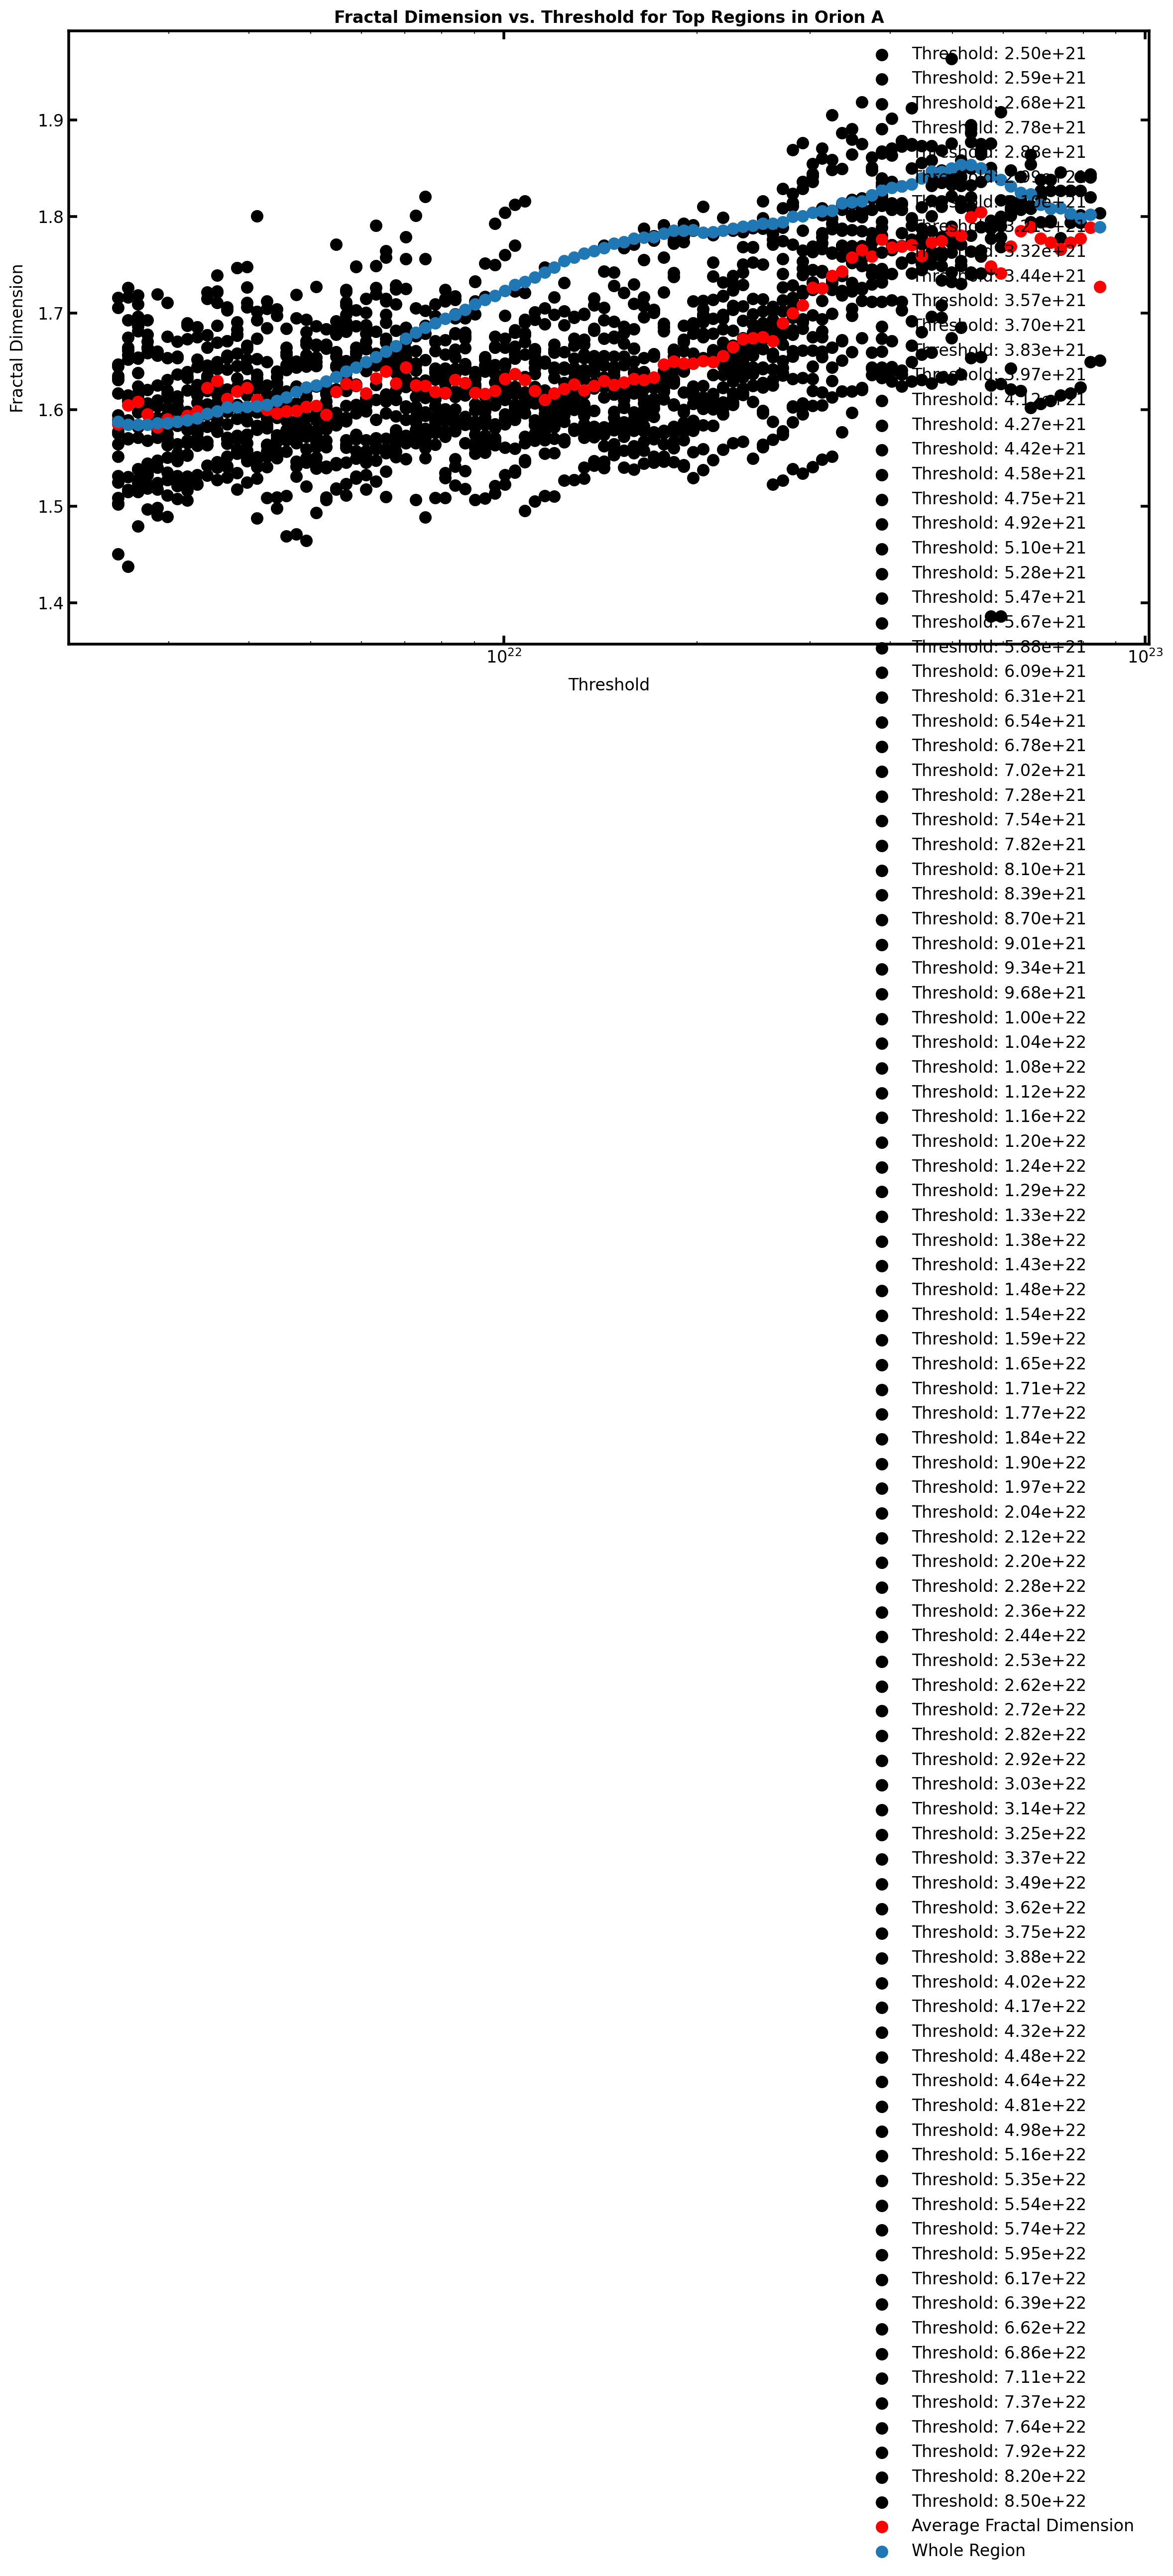

In [ ]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OA = convert_to_mass(N_H2_OA)

thresholds = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100) 

if os.path.exists("top_regions_data_OA.pkl"):
    top_regions_data_OA = load_regions_from_pickle("top_regions_data_OA.pkl")
else:
    top_regions_data_OA = track_largest_regions_NEW(N_H2_OA, M_H2_OA, thresholds, pc_per_px, num_top_regions=20, min_region_size_px=15)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OA.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OA.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OA["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion A", fontweight='bold')
plt.legend()
plt.show()

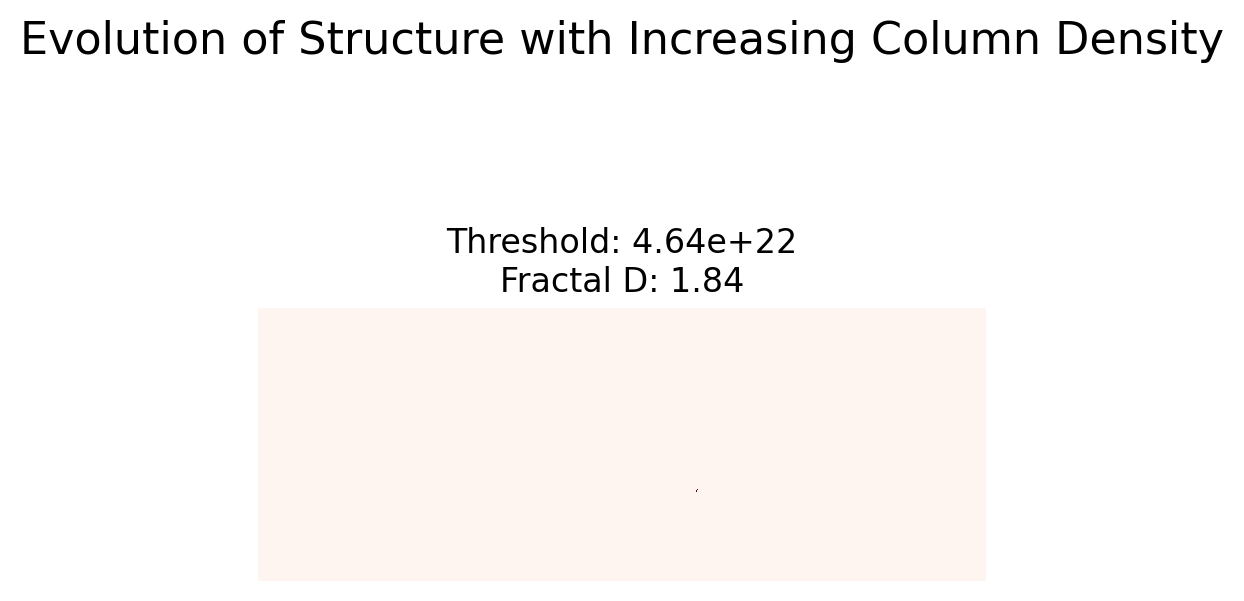

In [16]:
# Plot the evolution of selected structures with increasing column density and fractal dimension

def plot_structure_evolution(region_dict, tree_pairs, num_steps=4):
    """
    Plot the evolution of a structure along a tree (parent-child chain) with increasing threshold.
    Shows the region mask and fractal dimension at each step.
    """
    # Find a chain (longest sequence of nested regions)
    # Build a mapping from child to parent for easy traversal
    child_to_parent = {child: parent for parent, child in tree_pairs}
    # Find a leaf (child not a parent)
    all_parents = set(parent for parent, _ in tree_pairs)
    all_children = set(child for _, child in tree_pairs)
    leaves = all_children - all_parents
    if not leaves:
        print("No leaf found in tree structure.")
        return

    # Pick the first leaf and trace back to the root
    chain = []
    current = next(iter(leaves))
    while current in child_to_parent:
        parent = child_to_parent[current]
        chain.append((parent, current))
        current = parent
    chain = chain[::-1]  # from root to leaf

    # Select up to num_steps along the chain (evenly spaced)
    if len(chain) < num_steps:
        steps = chain
    else:
        idxs = np.linspace(0, len(chain)-1, num_steps, dtype=int)
        steps = [chain[i] for i in idxs]

    fig, axes = plt.subplots(1, len(steps), figsize=(4*len(steps), 4))
    if len(steps) == 1:
        axes = [axes]
    for ax, (parent_key, child_key) in zip(axes, steps):
        region = region_dict[child_key]
        mask = region["region_mask"]
        ax.imshow(mask, cmap='Reds', origin='lower')
        ax.set_title(
            f"Threshold: {float(child_key.split('_')[0]):.2e}\n"
            f"Fractal D: {region['fractal_dimension']:.2f}"
        )
        ax.axis('off')
    plt.suptitle("Evolution of Structure with Increasing Column Density", fontsize=16)
    plt.tight_layout()
    plt.show()

def find_trees_in_regions(region_dict):
    # Convert region masks to a list for easier iteration
    region_items = list(region_dict.items())
    n = len(region_items)
    trees = []

    # For each region, check if it is fully contained in any larger region
    for i in range(n):
        key_i, data_i = region_items[i]
        mask_i = data_i["region_mask"]
        area_i = np.sum(mask_i)
        contained_in = None
        for j in range(n):
            if i == j:
                continue
            key_j, data_j = region_items[j]
            mask_j = data_j["region_mask"]
            area_j = np.sum(mask_j)
            # Only consider larger regions
            if area_j <= area_i:
                continue
            # Check if mask_i is fully contained in mask_j
            if np.all(mask_i[mask_i] == mask_j[mask_i]):
                contained_in = key_j
                break
        if contained_in is not None:
            trees.append((contained_in, key_i))
    return trees

# Find trees (parent-child pairs) in the OA regions
trees = find_trees_in_regions(top_regions_data_OA)

# Use the OA regions and trees as an example
plot_structure_evolution(top_regions_data_OA, trees, num_steps=5)

[2.4999999999999995e+21] Found 788 regions, saved 20.
[2.5906544706295043e+21] Found 692 regions, saved 20.
[2.6845962344770563e+21] Found 695 regions, saved 20.
[2.781944494673271e+21] Found 662 regions, saved 20.
[2.88282277686738e+21] Found 592 regions, saved 20.
[2.987359085969617e+21] Found 514 regions, saved 20.
[3.095686068577144e+21] Found 532 regions, saved 20.
[3.2079411812899425e+21] Found 537 regions, saved 20.
[3.3242668651301144e+21] Found 508 regions, saved 20.
[3.4448107262859726e+21] Found 485 regions, saved 20.
[3.569725723410091e+21] Found 422 regions, saved 20.
[3.6991703617093994e+21] Found 420 regions, saved 20.
[3.833308894073048e+21] Found 393 regions, saved 20.
[3.972311529493674e+21] Found 352 regions, saved 20.
[4.1163546490463993e+21] Found 326 regions, saved 20.
[4.2656210296994414e+21] Found 284 regions, saved 20.
[4.4203000762408365e+21] Found 256 regions, saved 20.
[4.5805880616149063e+21] Found 258 regions, saved 20.
[4.746688375973919e+21] Found 232 re

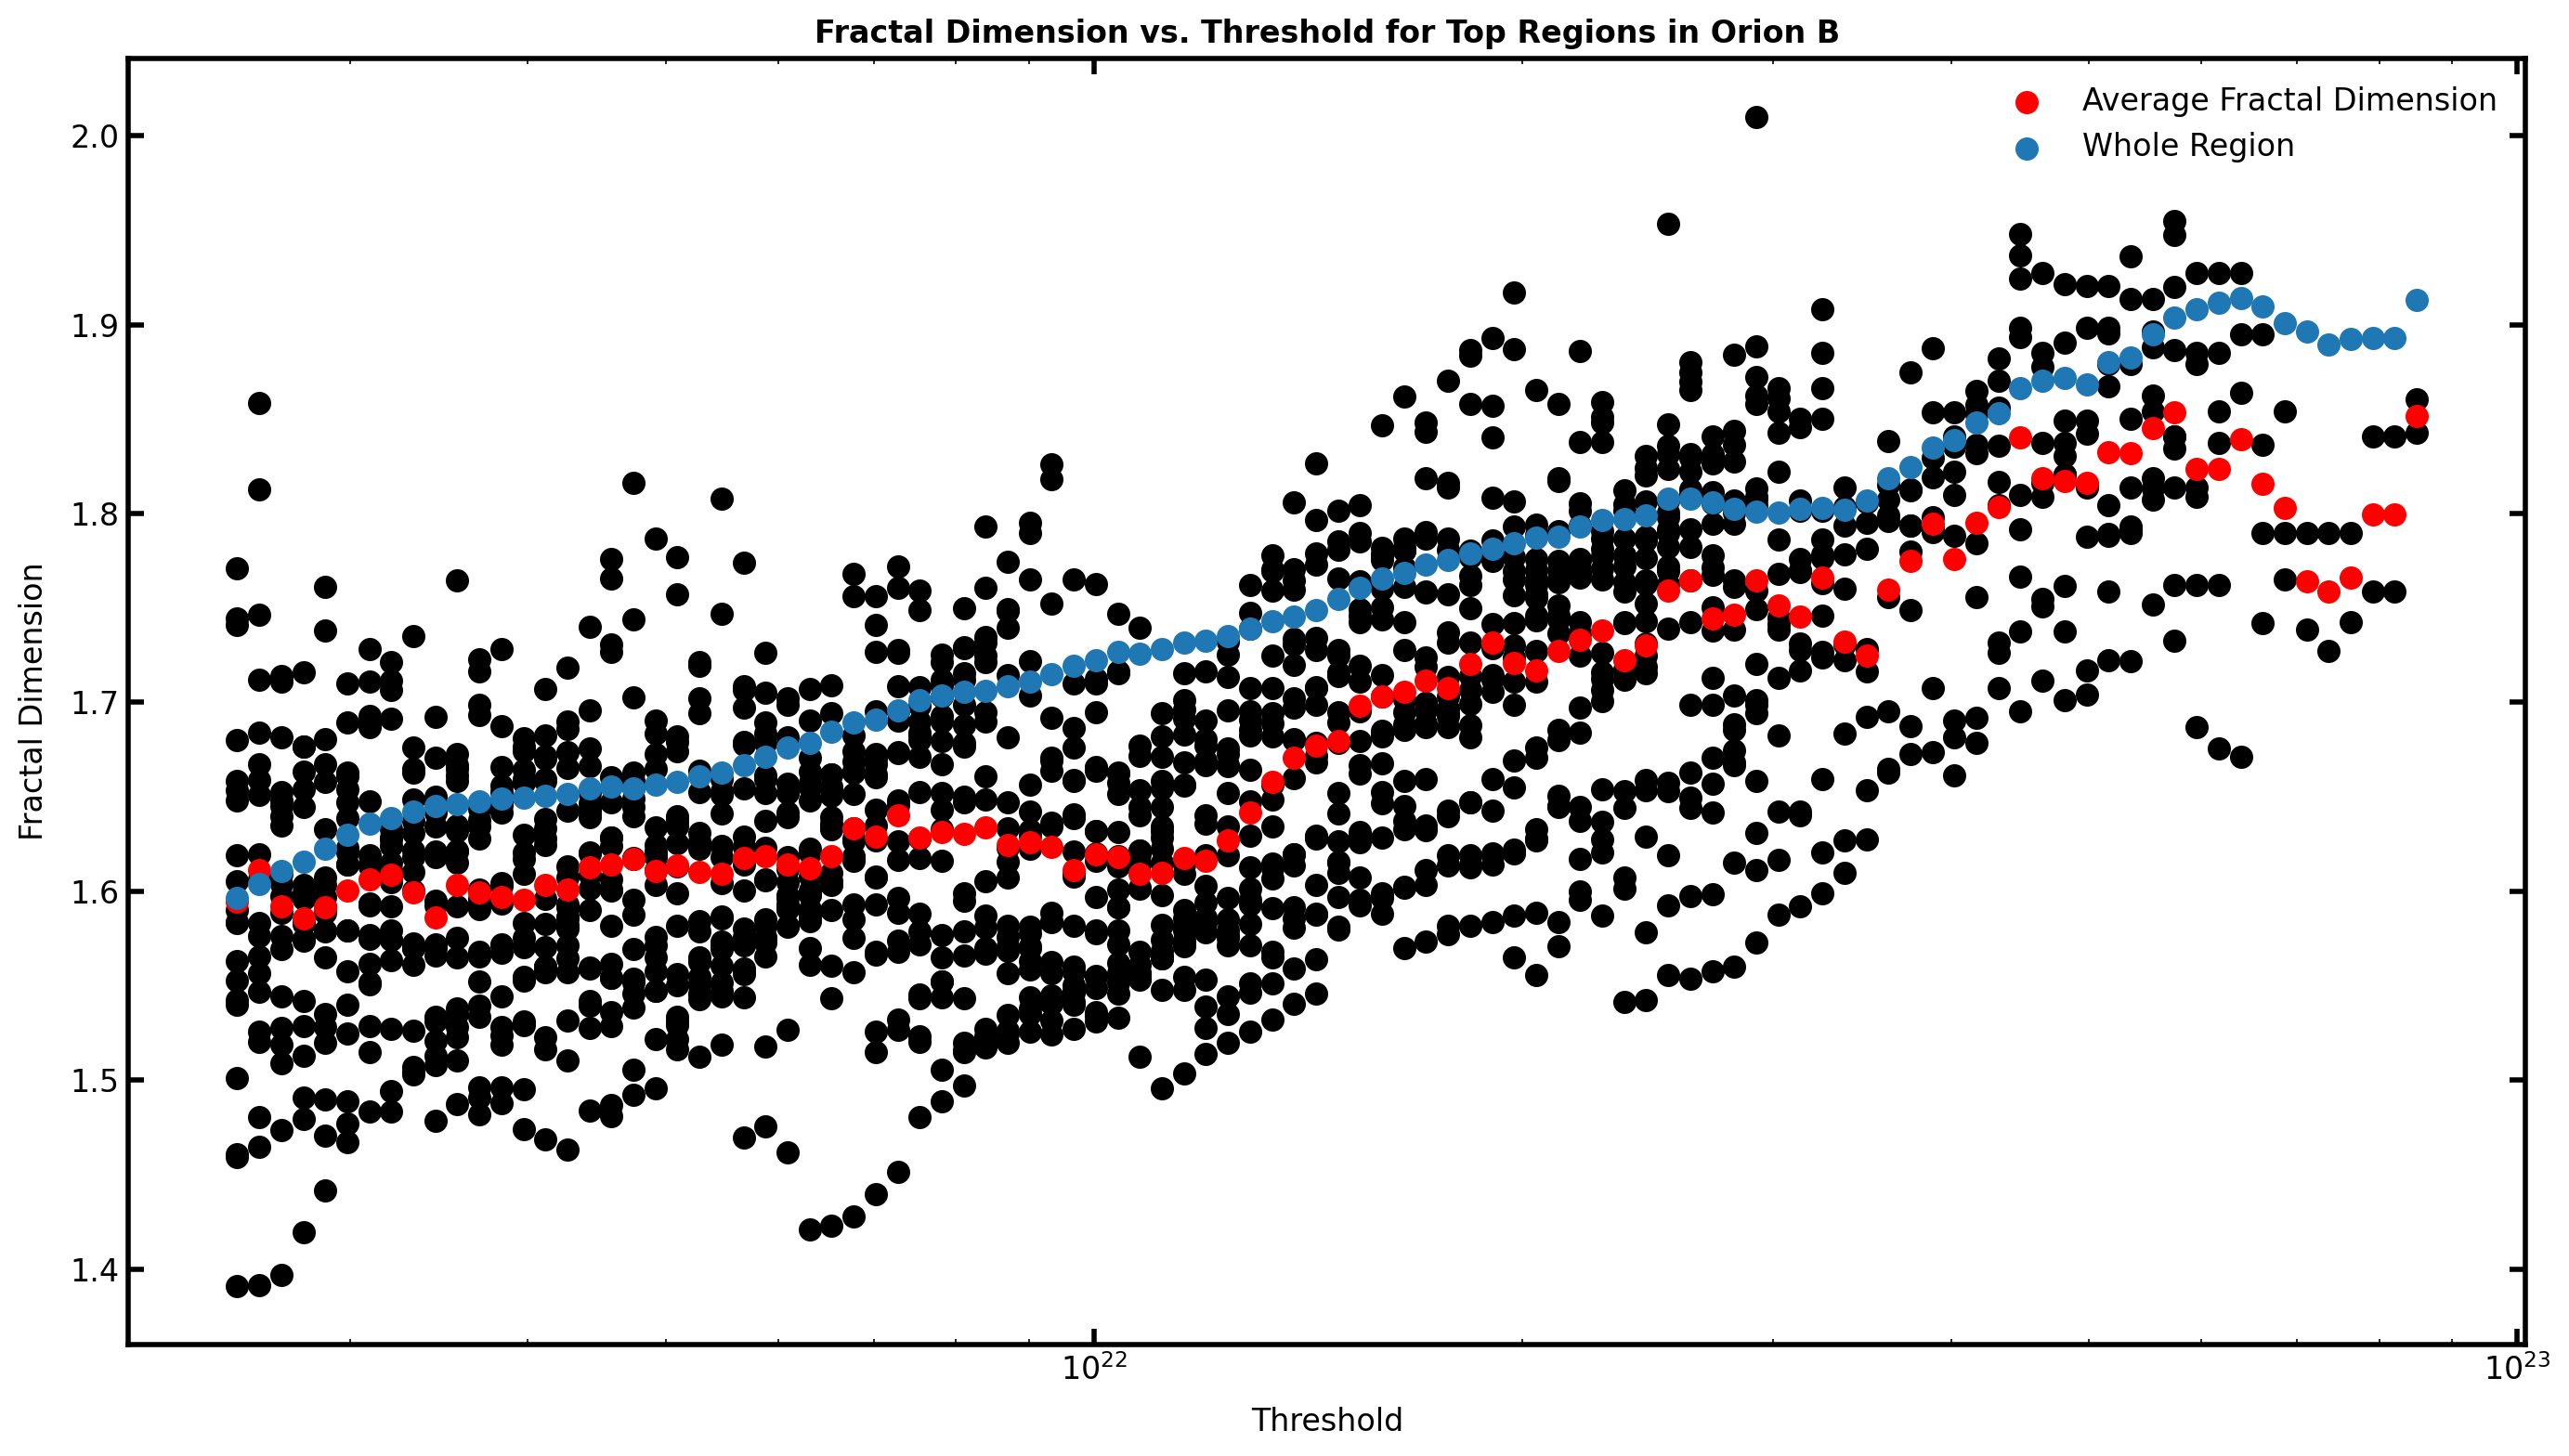

In [10]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OB = convert_to_mass(N_H2_OB)

thresholds = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100) 

if os.path.exists("top_regions_data_OB.pkl"):
    top_regions_data_OB = load_regions_from_pickle("top_regions_data_OB.pkl")
else:
    top_regions_data_OB = track_largest_regions_NEW(N_H2_OB, M_H2_OB, thresholds, pc_per_px, num_top_regions=20, min_region_size_px=15)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OB.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OB.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OB["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion B", fontweight='bold')
plt.legend()
plt.show()

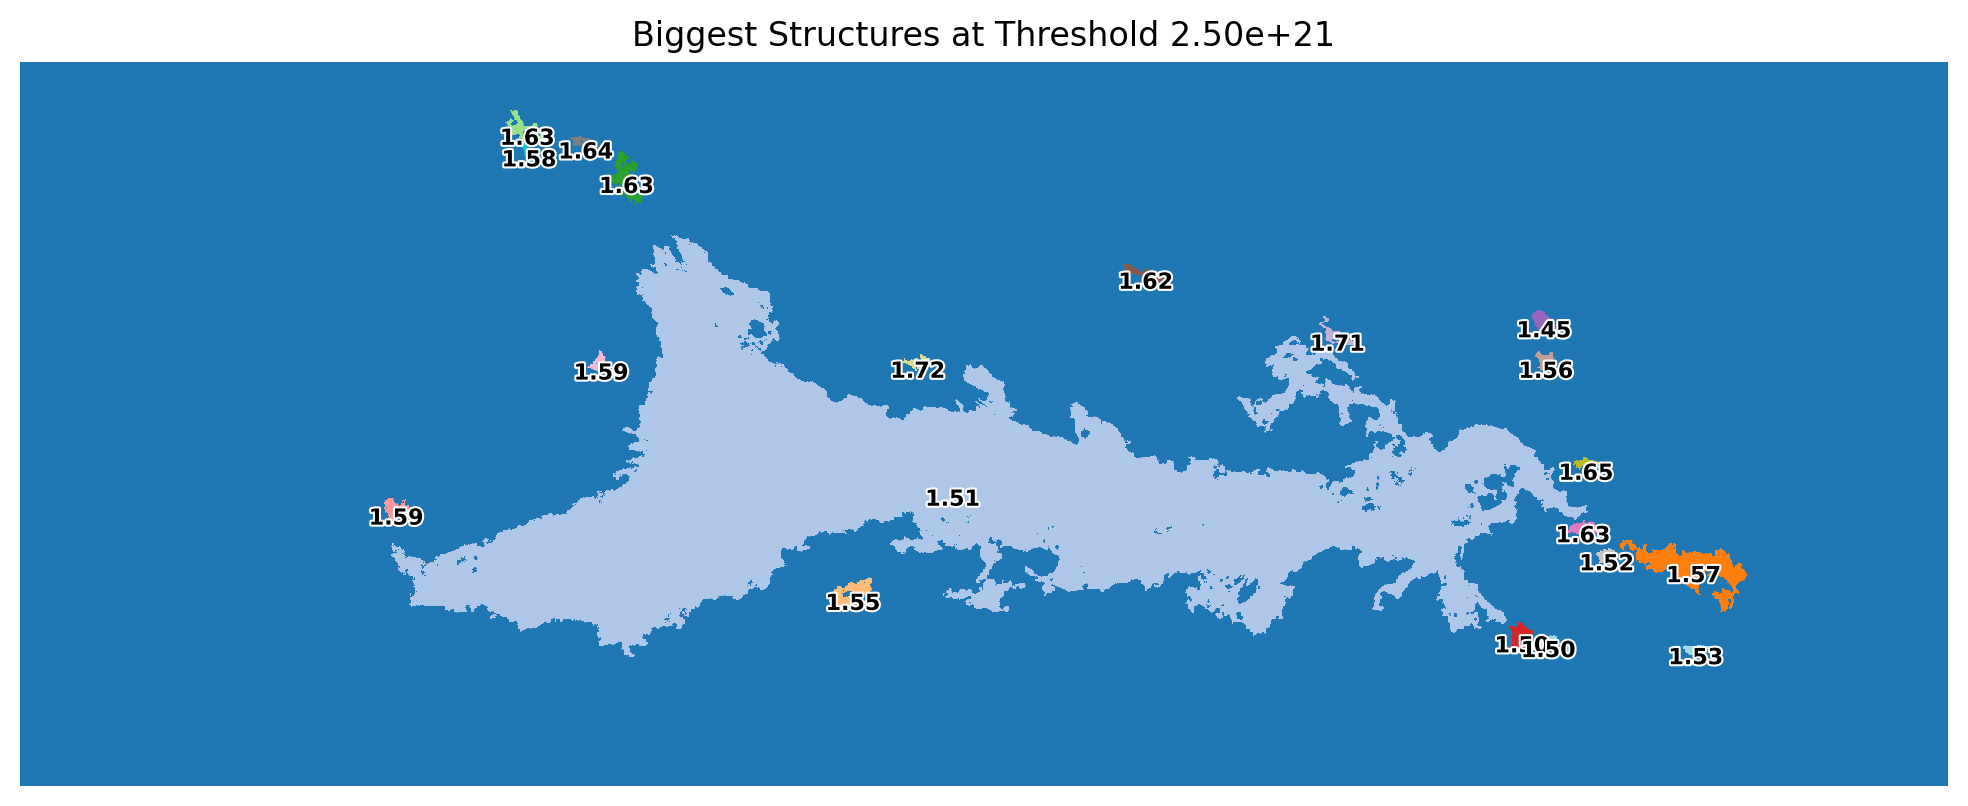

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from scipy.ndimage import center_of_mass

# Create the visualization mask
first_threshold = thresholds_full[0]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


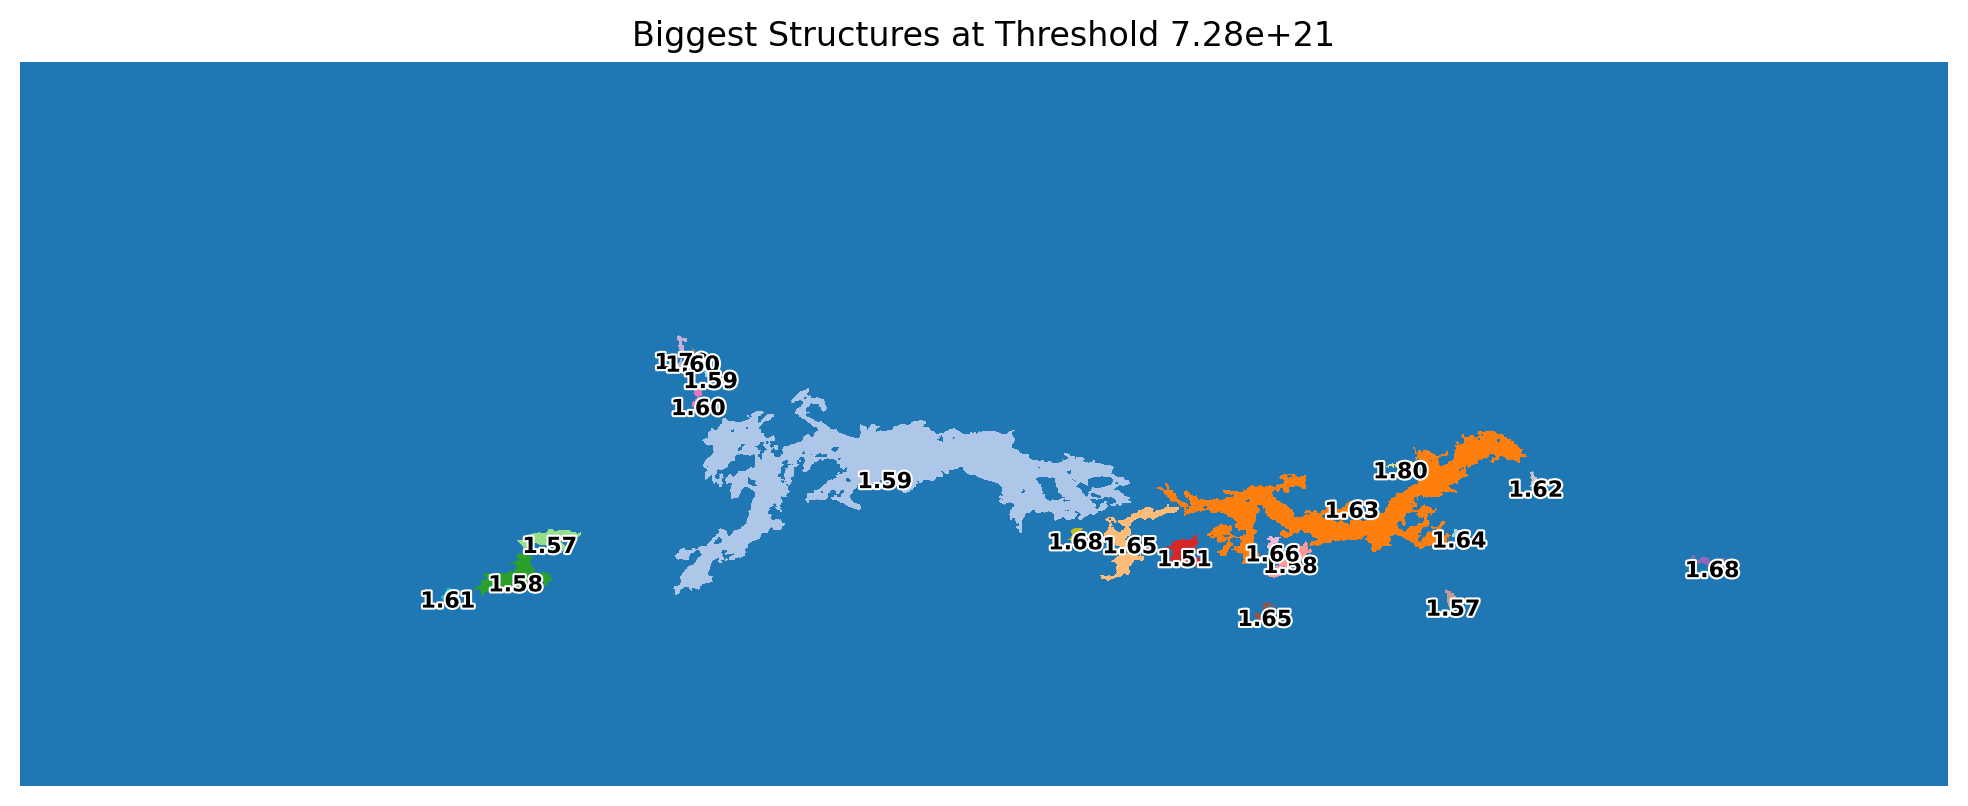

In [6]:
# Create the visualization mask
first_threshold = thresholds_full[30]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


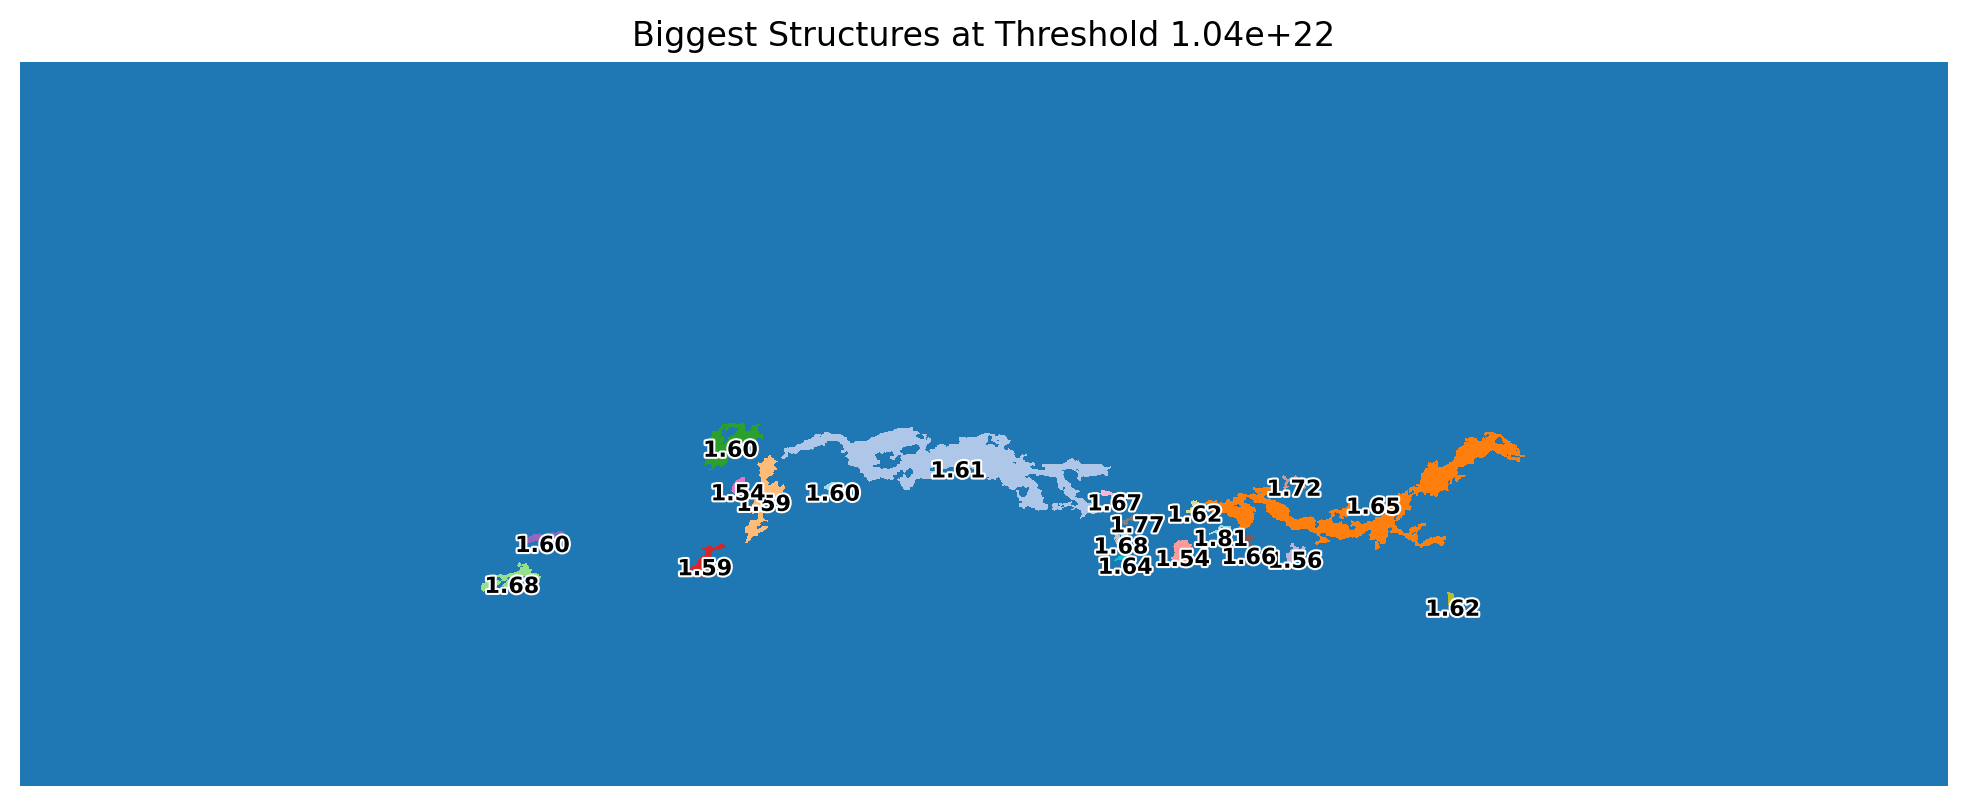

In [7]:
# Create the visualization mask
first_threshold = thresholds_full[40]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


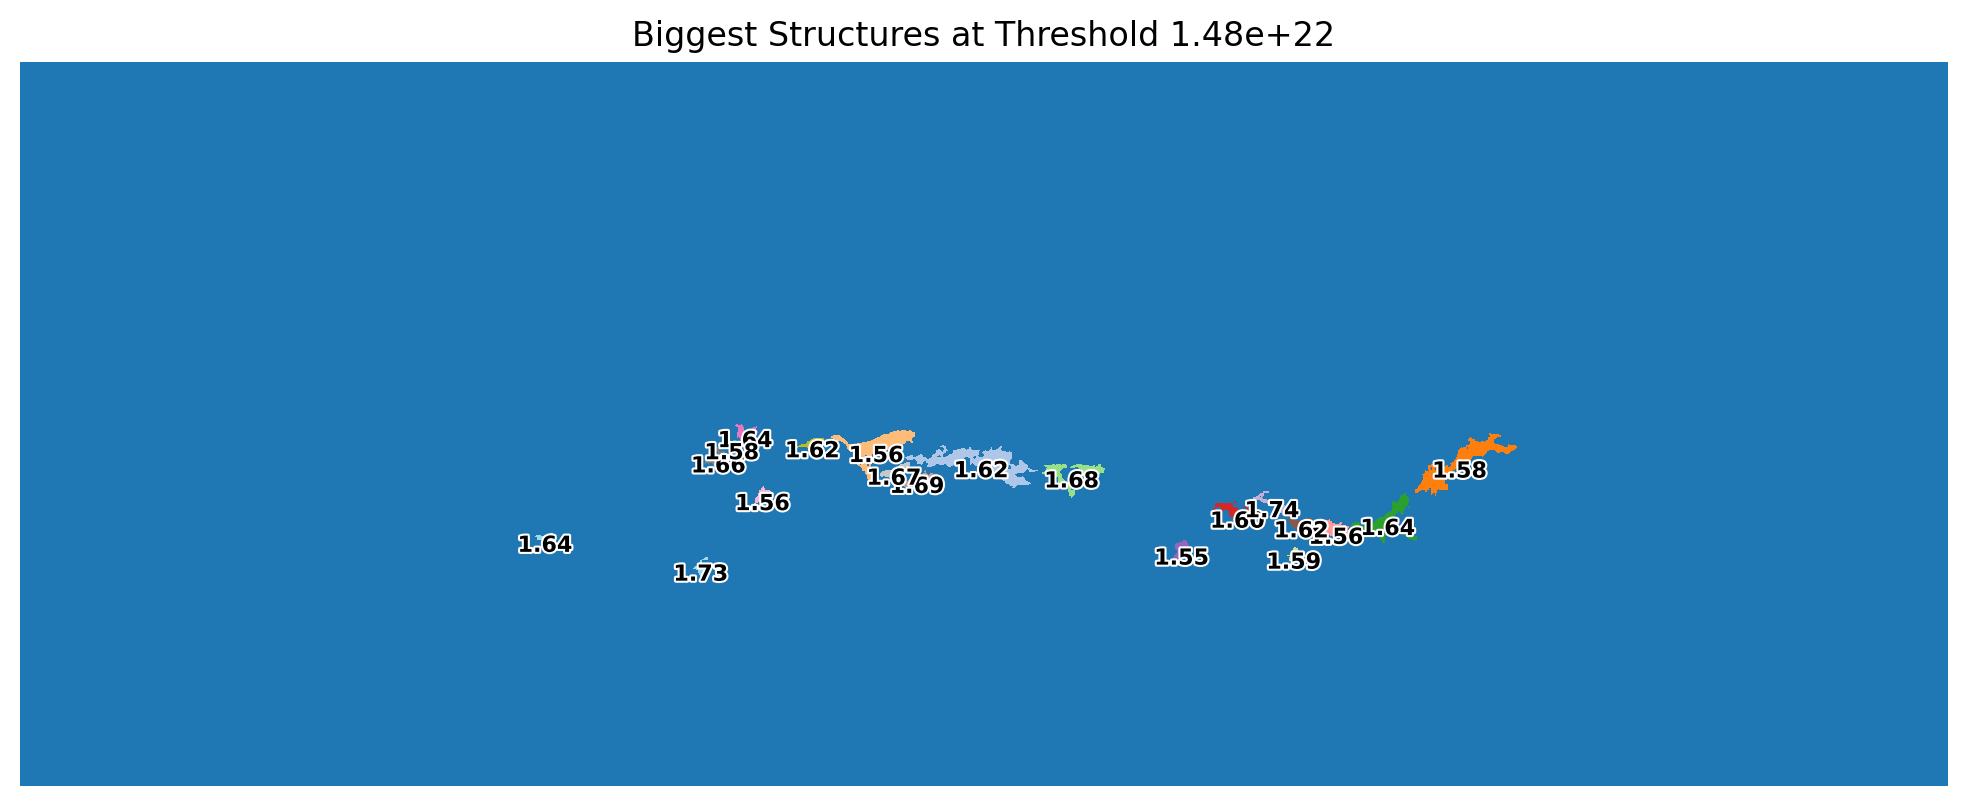

In [9]:
# Create the visualization mask
first_threshold = thresholds_full[50]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 10

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


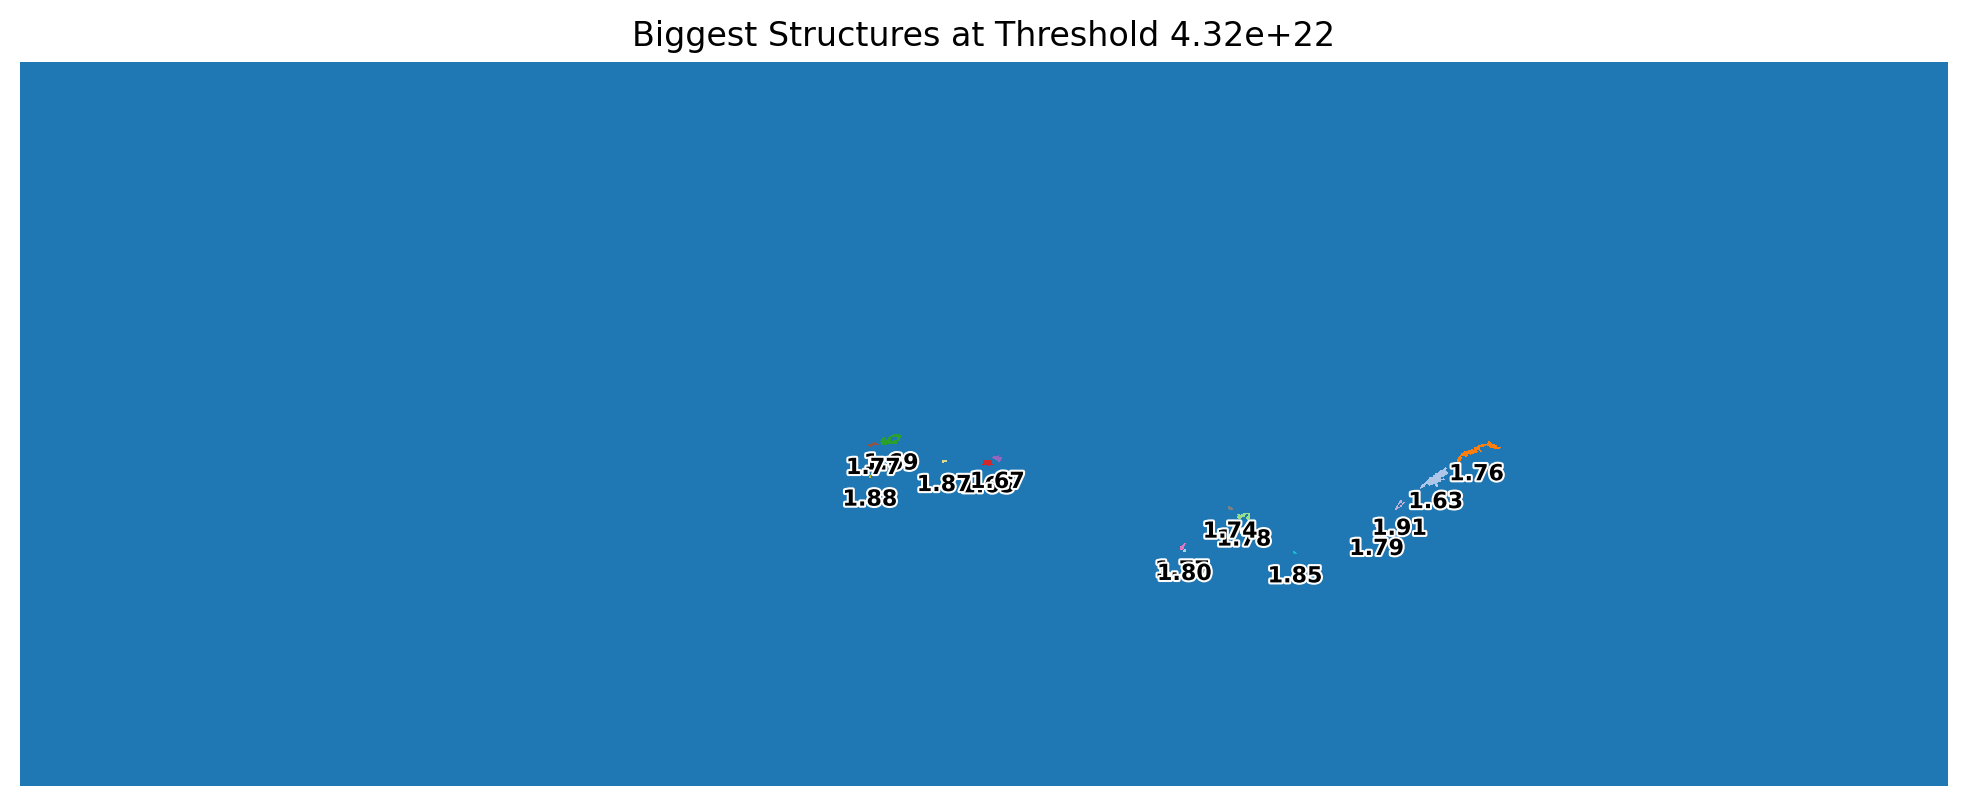

In [ ]:
# Create the visualization mask
first_threshold = thresholds_full[80]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OA.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OA.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OA[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OA[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 30

    # Get fractal dimension
    fd = top_regions_data_OA[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


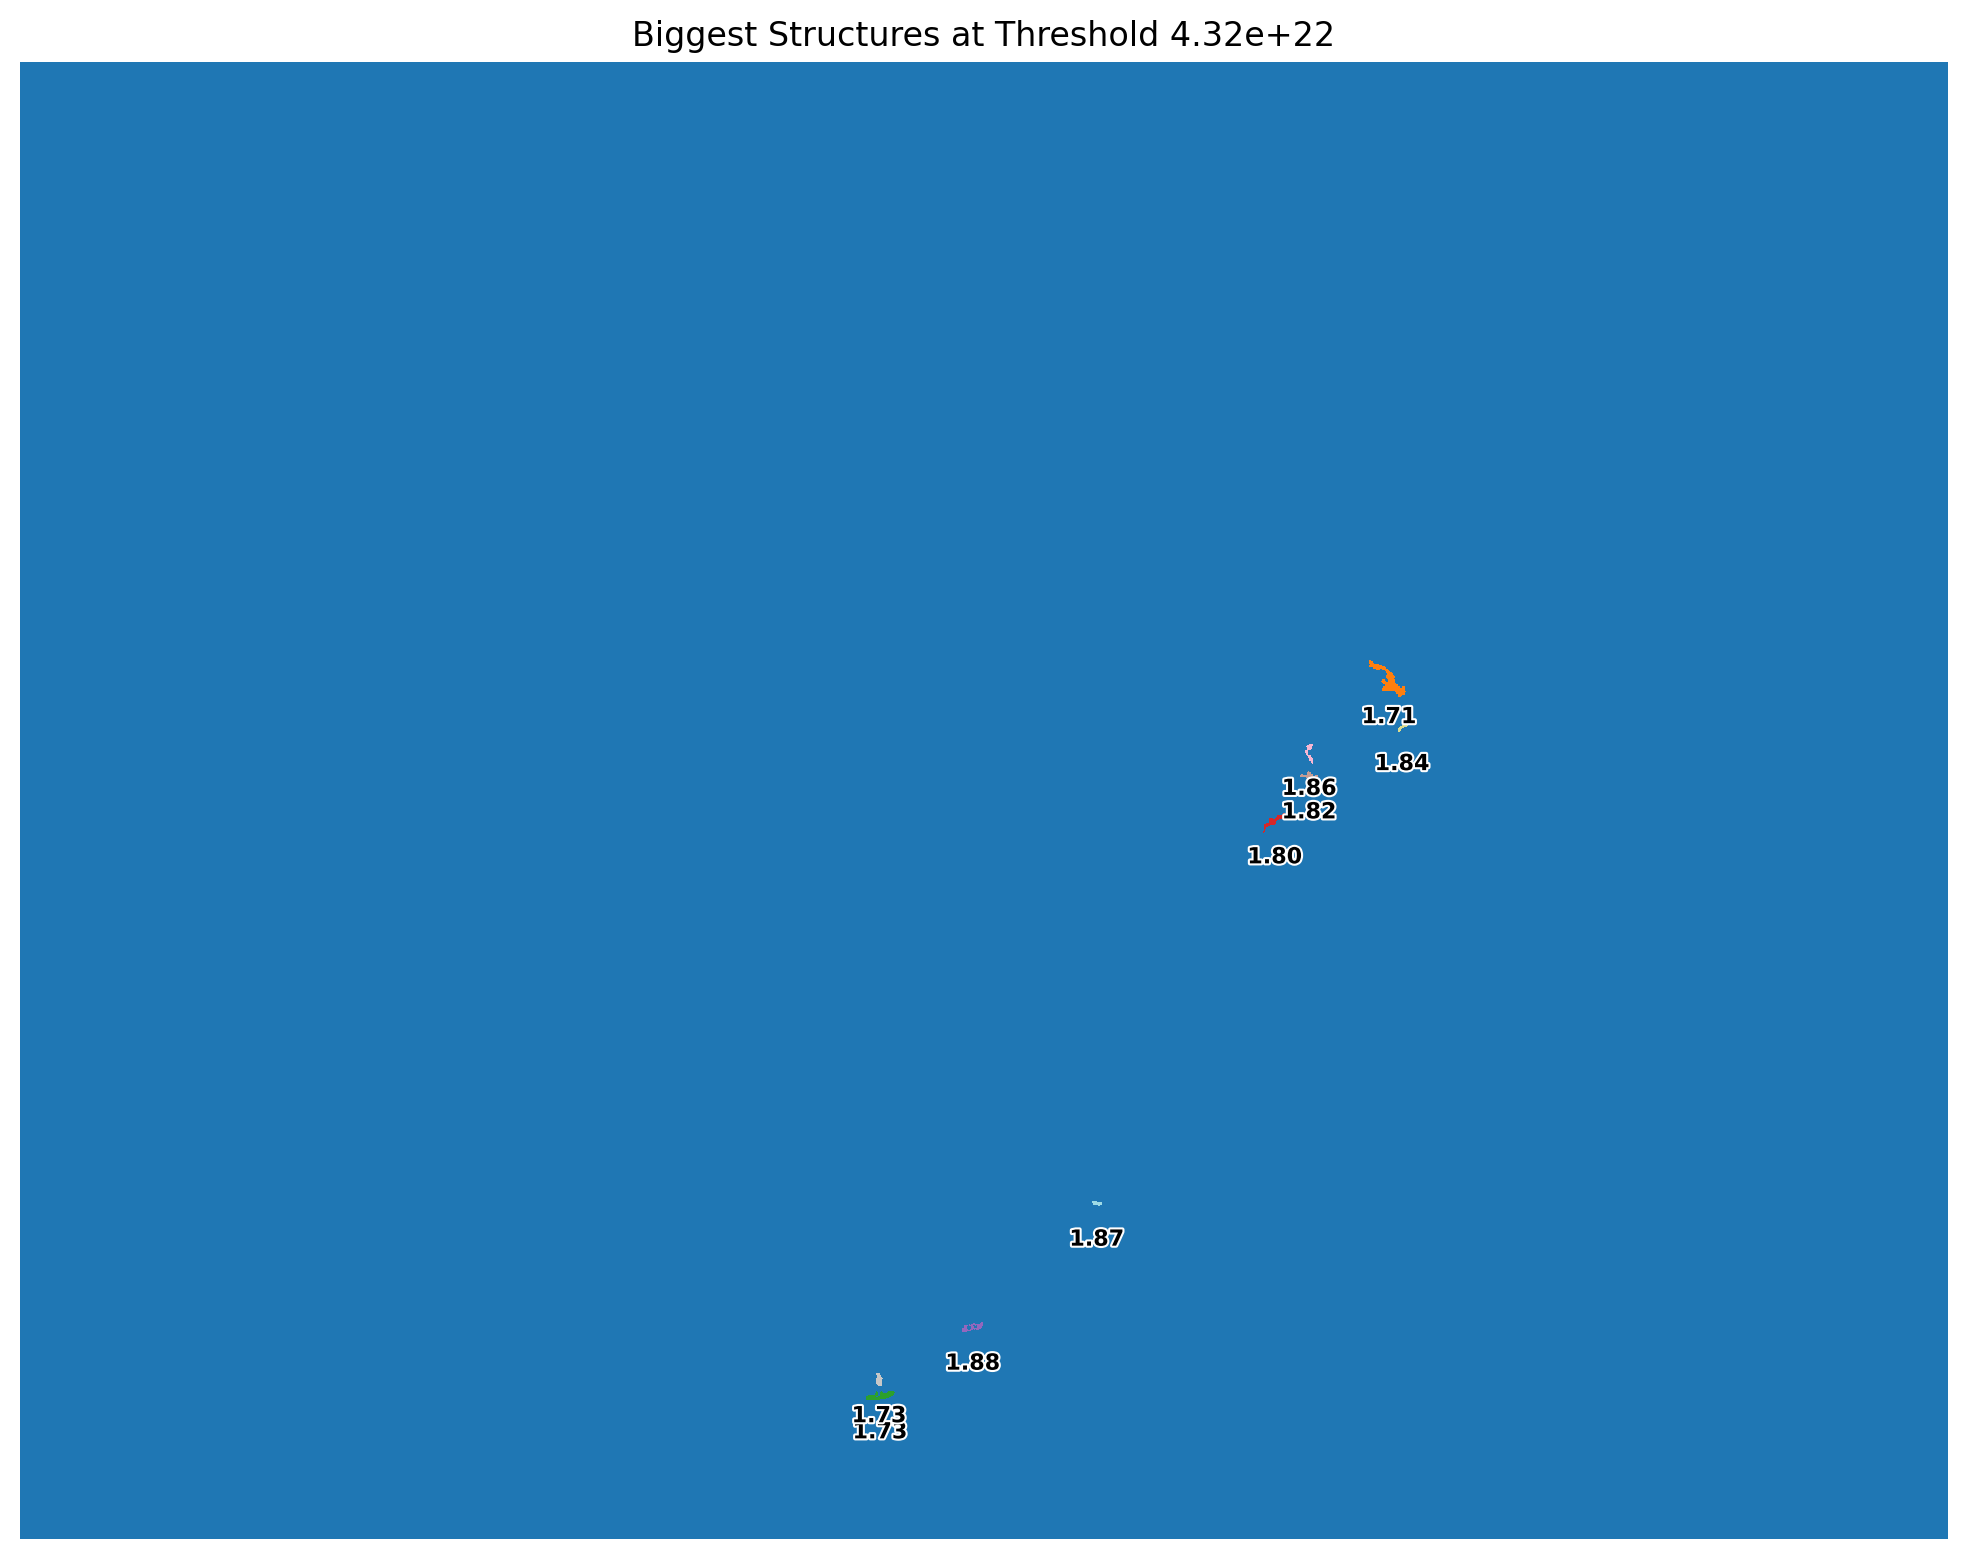

In [15]:
# Create the visualization mask
first_threshold = thresholds_full[80]
region_keys_first_threshold = [
    key for key, data in top_regions_data_OB.items()
    if np.isclose(data["threshold"], first_threshold)
]

example_mask = next(iter(top_regions_data_OB.values()))["region_mask"]
all_regions_mask = np.zeros_like(example_mask, dtype=int)

for idx, key in enumerate(region_keys_first_threshold, 1):
    all_regions_mask[top_regions_data_OB[key]["region_mask"]] = idx

plt.figure(figsize=(10, 10))
plt.imshow(all_regions_mask, cmap='tab20', origin='lower')

for idx, key in enumerate(region_keys_first_threshold, 1):
    mask = top_regions_data_OB[key]["region_mask"]
    if not np.any(mask):
        continue

    # Smarter placement: use center of mass instead of mean
    y, x = center_of_mass(mask)
    y = y - 30

    # Get fractal dimension
    fd = top_regions_data_OB[key]["fractal_dimension"]

    # Format the text with a white outline (halo effect)
    txt = plt.text(x, y, f"{fd:.2f}",
                   color='black', fontsize=8, ha='center', va='center', fontweight='bold')
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

plt.title(f"Biggest Structures at Threshold {first_threshold:.2e}")
plt.axis('off')
plt.tight_layout()
plt.show()


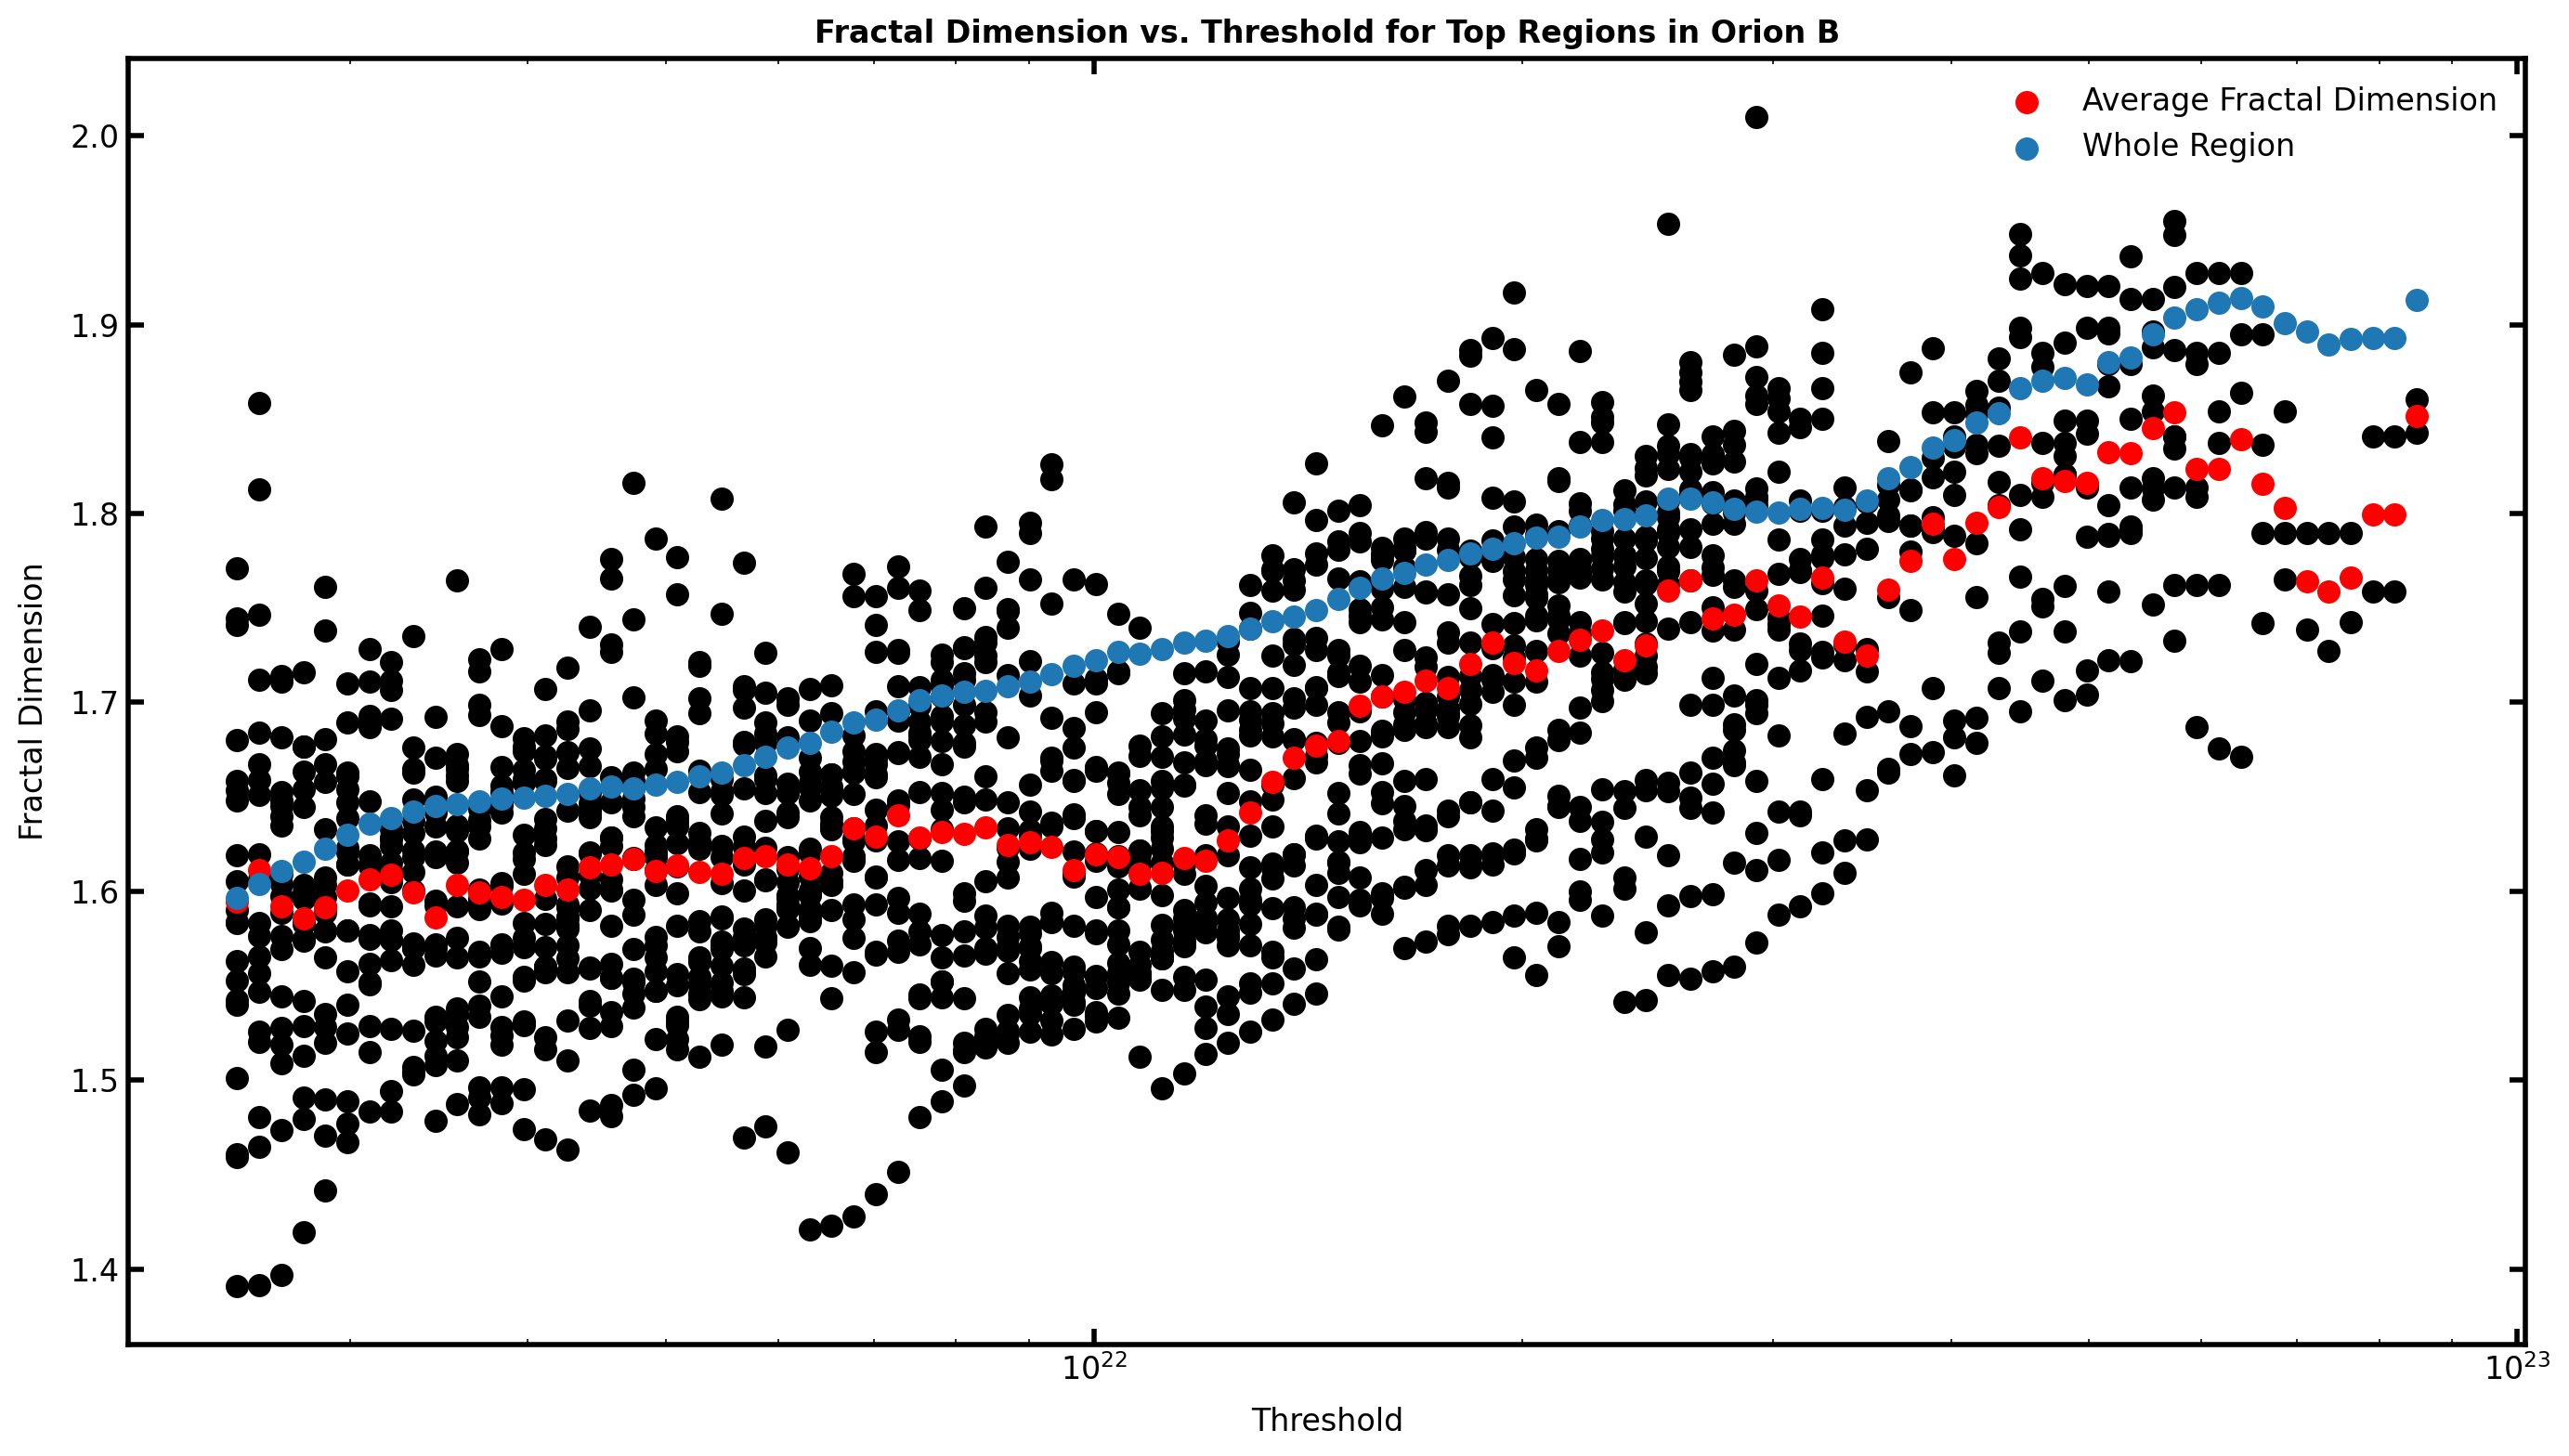

In [14]:
plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OB.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OB["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion B", fontweight='bold')
plt.legend()
plt.show()

In [109]:
# Identify "trees" in top_regions_data_OA: a tree is a set of regions where the region_mask of a smaller structure is fully contained in a larger one.

def find_trees_in_regions(region_dict):
    # Convert region masks to a list for easier iteration
    region_items = list(region_dict.items())
    n = len(region_items)
    trees = []

    # For each region, check if it is fully contained in any larger region
    for i in range(n):
        key_i, data_i = region_items[i]
        mask_i = data_i["region_mask"]
        area_i = np.sum(mask_i)
        contained_in = None
        for j in range(n):
            if i == j:
                continue
            key_j, data_j = region_items[j]
            mask_j = data_j["region_mask"]
            area_j = np.sum(mask_j)
            # Only consider larger regions
            if area_j <= area_i:
                continue
            # Check if mask_i is fully contained in mask_j
            if np.all(mask_i[mask_i] == mask_j[mask_i]):
                contained_in = key_j
                break
        if contained_in is not None:
            trees.append((contained_in, key_i))
    return trees

trees = find_trees_in_regions(top_regions_data_OA)
print("Found region pairs (parent, child) where child is fully contained in parent:")
for parent, child in trees:
    print(f"Parent: {parent}, Child: {child}")

Found region pairs (parent, child) where child is fully contained in parent:
Parent: 2.4999999999999995e+21_22, Child: 2.5906544706295043e+21_17
Parent: 2.4999999999999995e+21_80, Child: 2.5906544706295043e+21_66
Parent: 2.4999999999999995e+21_81, Child: 2.5906544706295043e+21_68
Parent: 2.4999999999999995e+21_702, Child: 2.5906544706295043e+21_685
Parent: 2.4999999999999995e+21_784, Child: 2.5906544706295043e+21_741
Parent: 2.4999999999999995e+21_26, Child: 2.5906544706295043e+21_21
Parent: 2.4999999999999995e+21_598, Child: 2.5906544706295043e+21_568
Parent: 2.4999999999999995e+21_252, Child: 2.5906544706295043e+21_225
Parent: 2.4999999999999995e+21_651, Child: 2.5906544706295043e+21_625
Parent: 2.4999999999999995e+21_22, Child: 2.6845962344770563e+21_19
Parent: 2.4999999999999995e+21_80, Child: 2.6845962344770563e+21_63
Parent: 2.4999999999999995e+21_22, Child: 2.6845962344770563e+21_351
Parent: 2.4999999999999995e+21_81, Child: 2.6845962344770563e+21_64
Parent: 2.4999999999999995e+

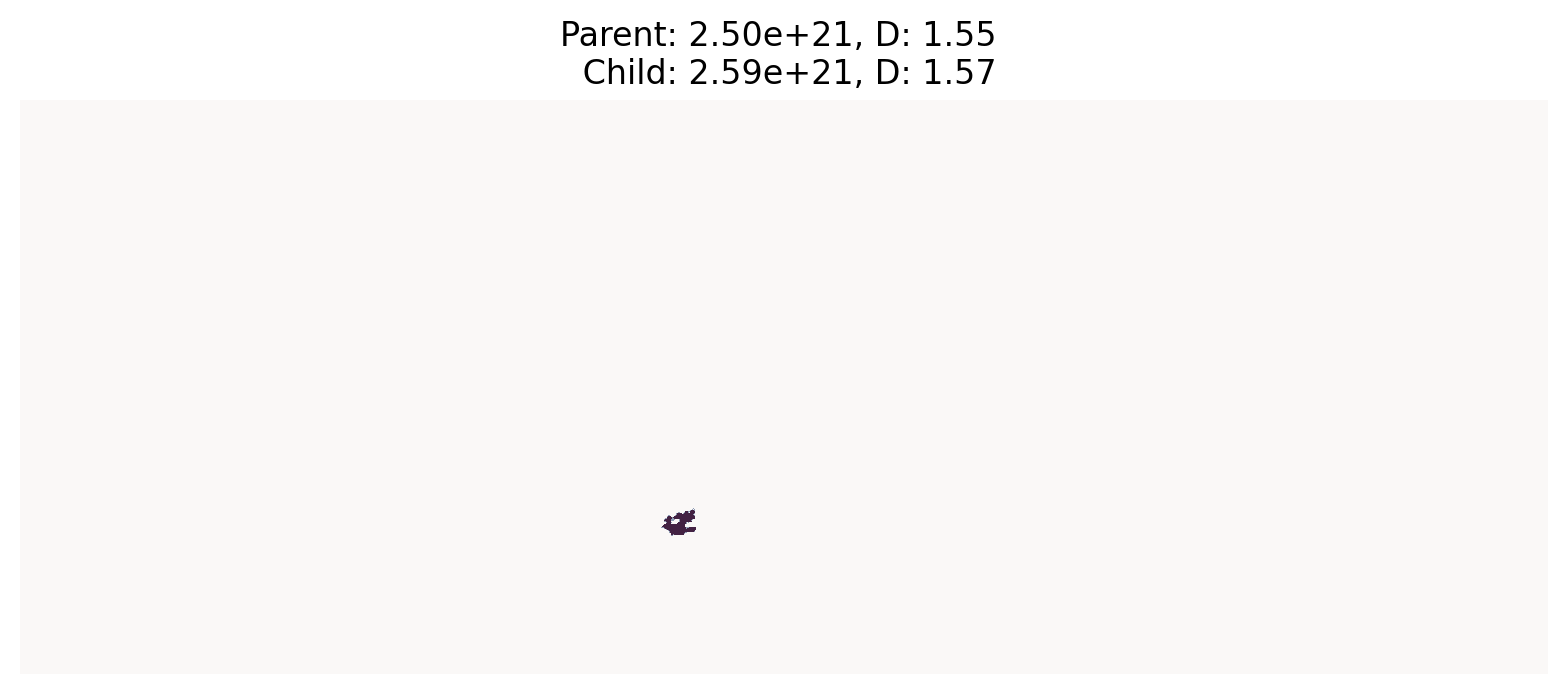

Max fractal_dimension in filtered_trees: 1.9630047912470099
1640


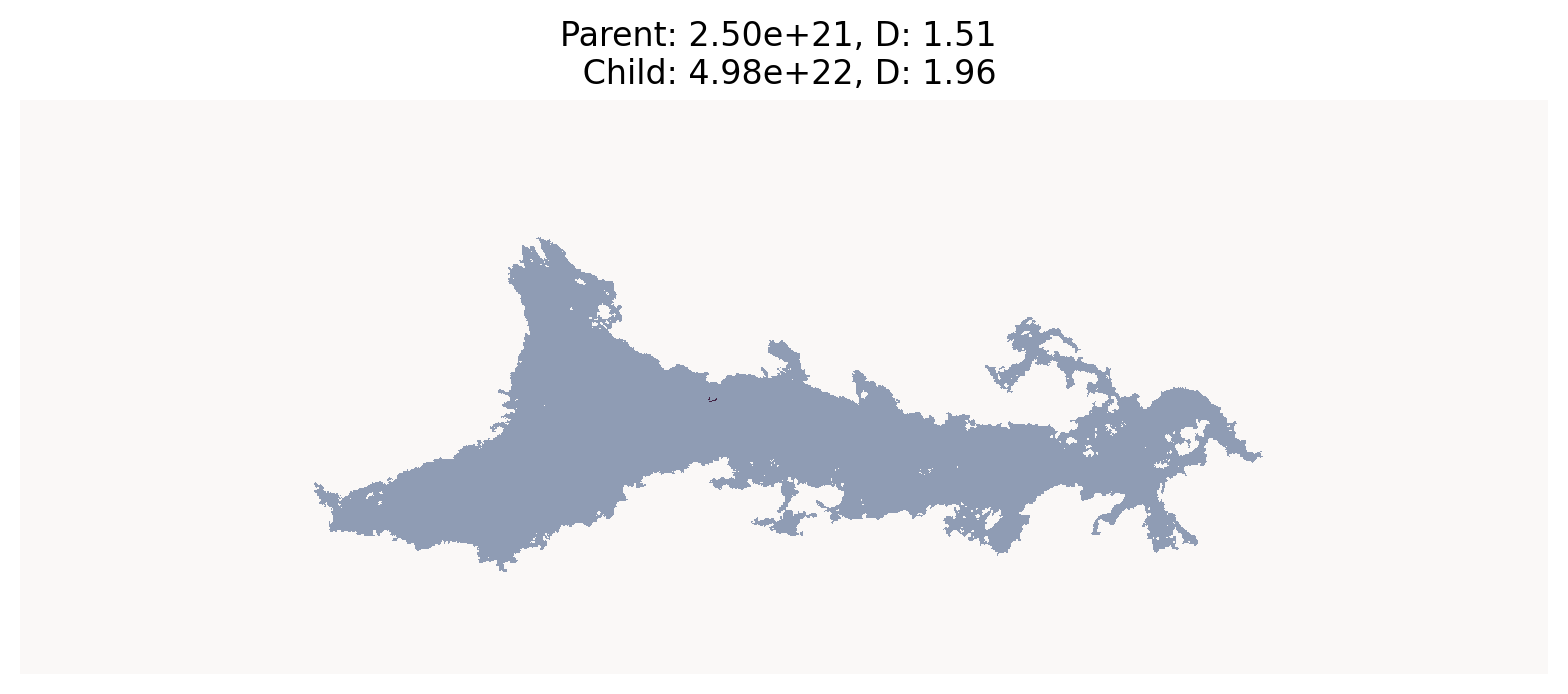

Plotted parent: 2.4999999999999995e+21_22, child: 4.98168961847443e+22_48 with max fractal_dimension: 1.9630047912470099


In [17]:
# Plot parent and child regions with their fractal dimensions

def plot_parent_child_regions(region_dict, parent_key, child_key, ax=None):
    parent_data = region_dict[parent_key]
    child_data = region_dict[child_key]
    parent_mask = parent_data["region_mask"]
    child_mask = child_data["region_mask"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig = None

    # Plot parent region in light blue
    ax.imshow(parent_mask, cmap='Blues', alpha=0.9, origin='lower', label='Parent')
    # Overlay child region in red
    ax.imshow(child_mask, cmap='Reds', alpha=0.5, origin='lower', label='Child')

    # Annotate fractal dimensions
    def format_key(key):
        # Extract the threshold part and format with 2 digits in scientific notation
        threshold_str = key.split('_')[0]
        threshold = float(threshold_str)
        return f"{threshold:.2e}"

    ax.set_title(
        f"Parent: {format_key(parent_key)}, D: {parent_data['fractal_dimension']:.2f} \n "
        f"Child: {format_key(child_key)}, D: {child_data['fractal_dimension']:.2f}",
        fontsize=12
    )
    ax.axis('off')

    if fig is not None:
        plt.show()

threshold_value = 5e22  # Set your desired threshold here

filtered_trees = [
    (parent_key, child_key)
    for parent_key, child_key in trees
    if float(child_key.split('_')[0]) < threshold_value
]

if filtered_trees:
    parent_key, child_key = filtered_trees[2]
    plot_parent_child_regions(top_regions_data_OA, parent_key, child_key)

    max_fd = max(
        top_regions_data_OA[child]['fractal_dimension']
        for _, child in filtered_trees
    )
    print("Max fractal_dimension in filtered_trees:", max_fd)
    
print(len(filtered_trees))
# Find the (parent_key, child_key) pair where the child's fractal_dimension is max_fd
for parent_key, child_key in filtered_trees:
    if np.isclose(top_regions_data_OA[child_key]['fractal_dimension'], max_fd):
        plot_parent_child_regions(top_regions_data_OA, parent_key, child_key)
        print(f"Plotted parent: {parent_key}, child: {child_key} with max fractal_dimension: {max_fd}")
        break

[2.4999999999999995e+21] Found 788 regions, saved 10.
[2.5906544706295043e+21] Found 692 regions, saved 10.
[2.6845962344770563e+21] Found 695 regions, saved 10.
[2.781944494673271e+21] Found 662 regions, saved 10.
[2.88282277686738e+21] Found 592 regions, saved 10.
[2.987359085969617e+21] Found 514 regions, saved 10.
[3.095686068577144e+21] Found 532 regions, saved 10.
[3.2079411812899425e+21] Found 537 regions, saved 10.
[3.3242668651301144e+21] Found 508 regions, saved 10.
[3.4448107262859726e+21] Found 485 regions, saved 10.
[3.569725723410091e+21] Found 422 regions, saved 10.
[3.6991703617093994e+21] Found 420 regions, saved 10.
[3.833308894073048e+21] Found 393 regions, saved 10.
[3.972311529493674e+21] Found 352 regions, saved 10.
[4.1163546490463993e+21] Found 326 regions, saved 10.
[4.2656210296994414e+21] Found 284 regions, saved 10.
[4.4203000762408365e+21] Found 256 regions, saved 10.
[4.5805880616149063e+21] Found 258 regions, saved 10.
[4.746688375973919e+21] Found 232 re

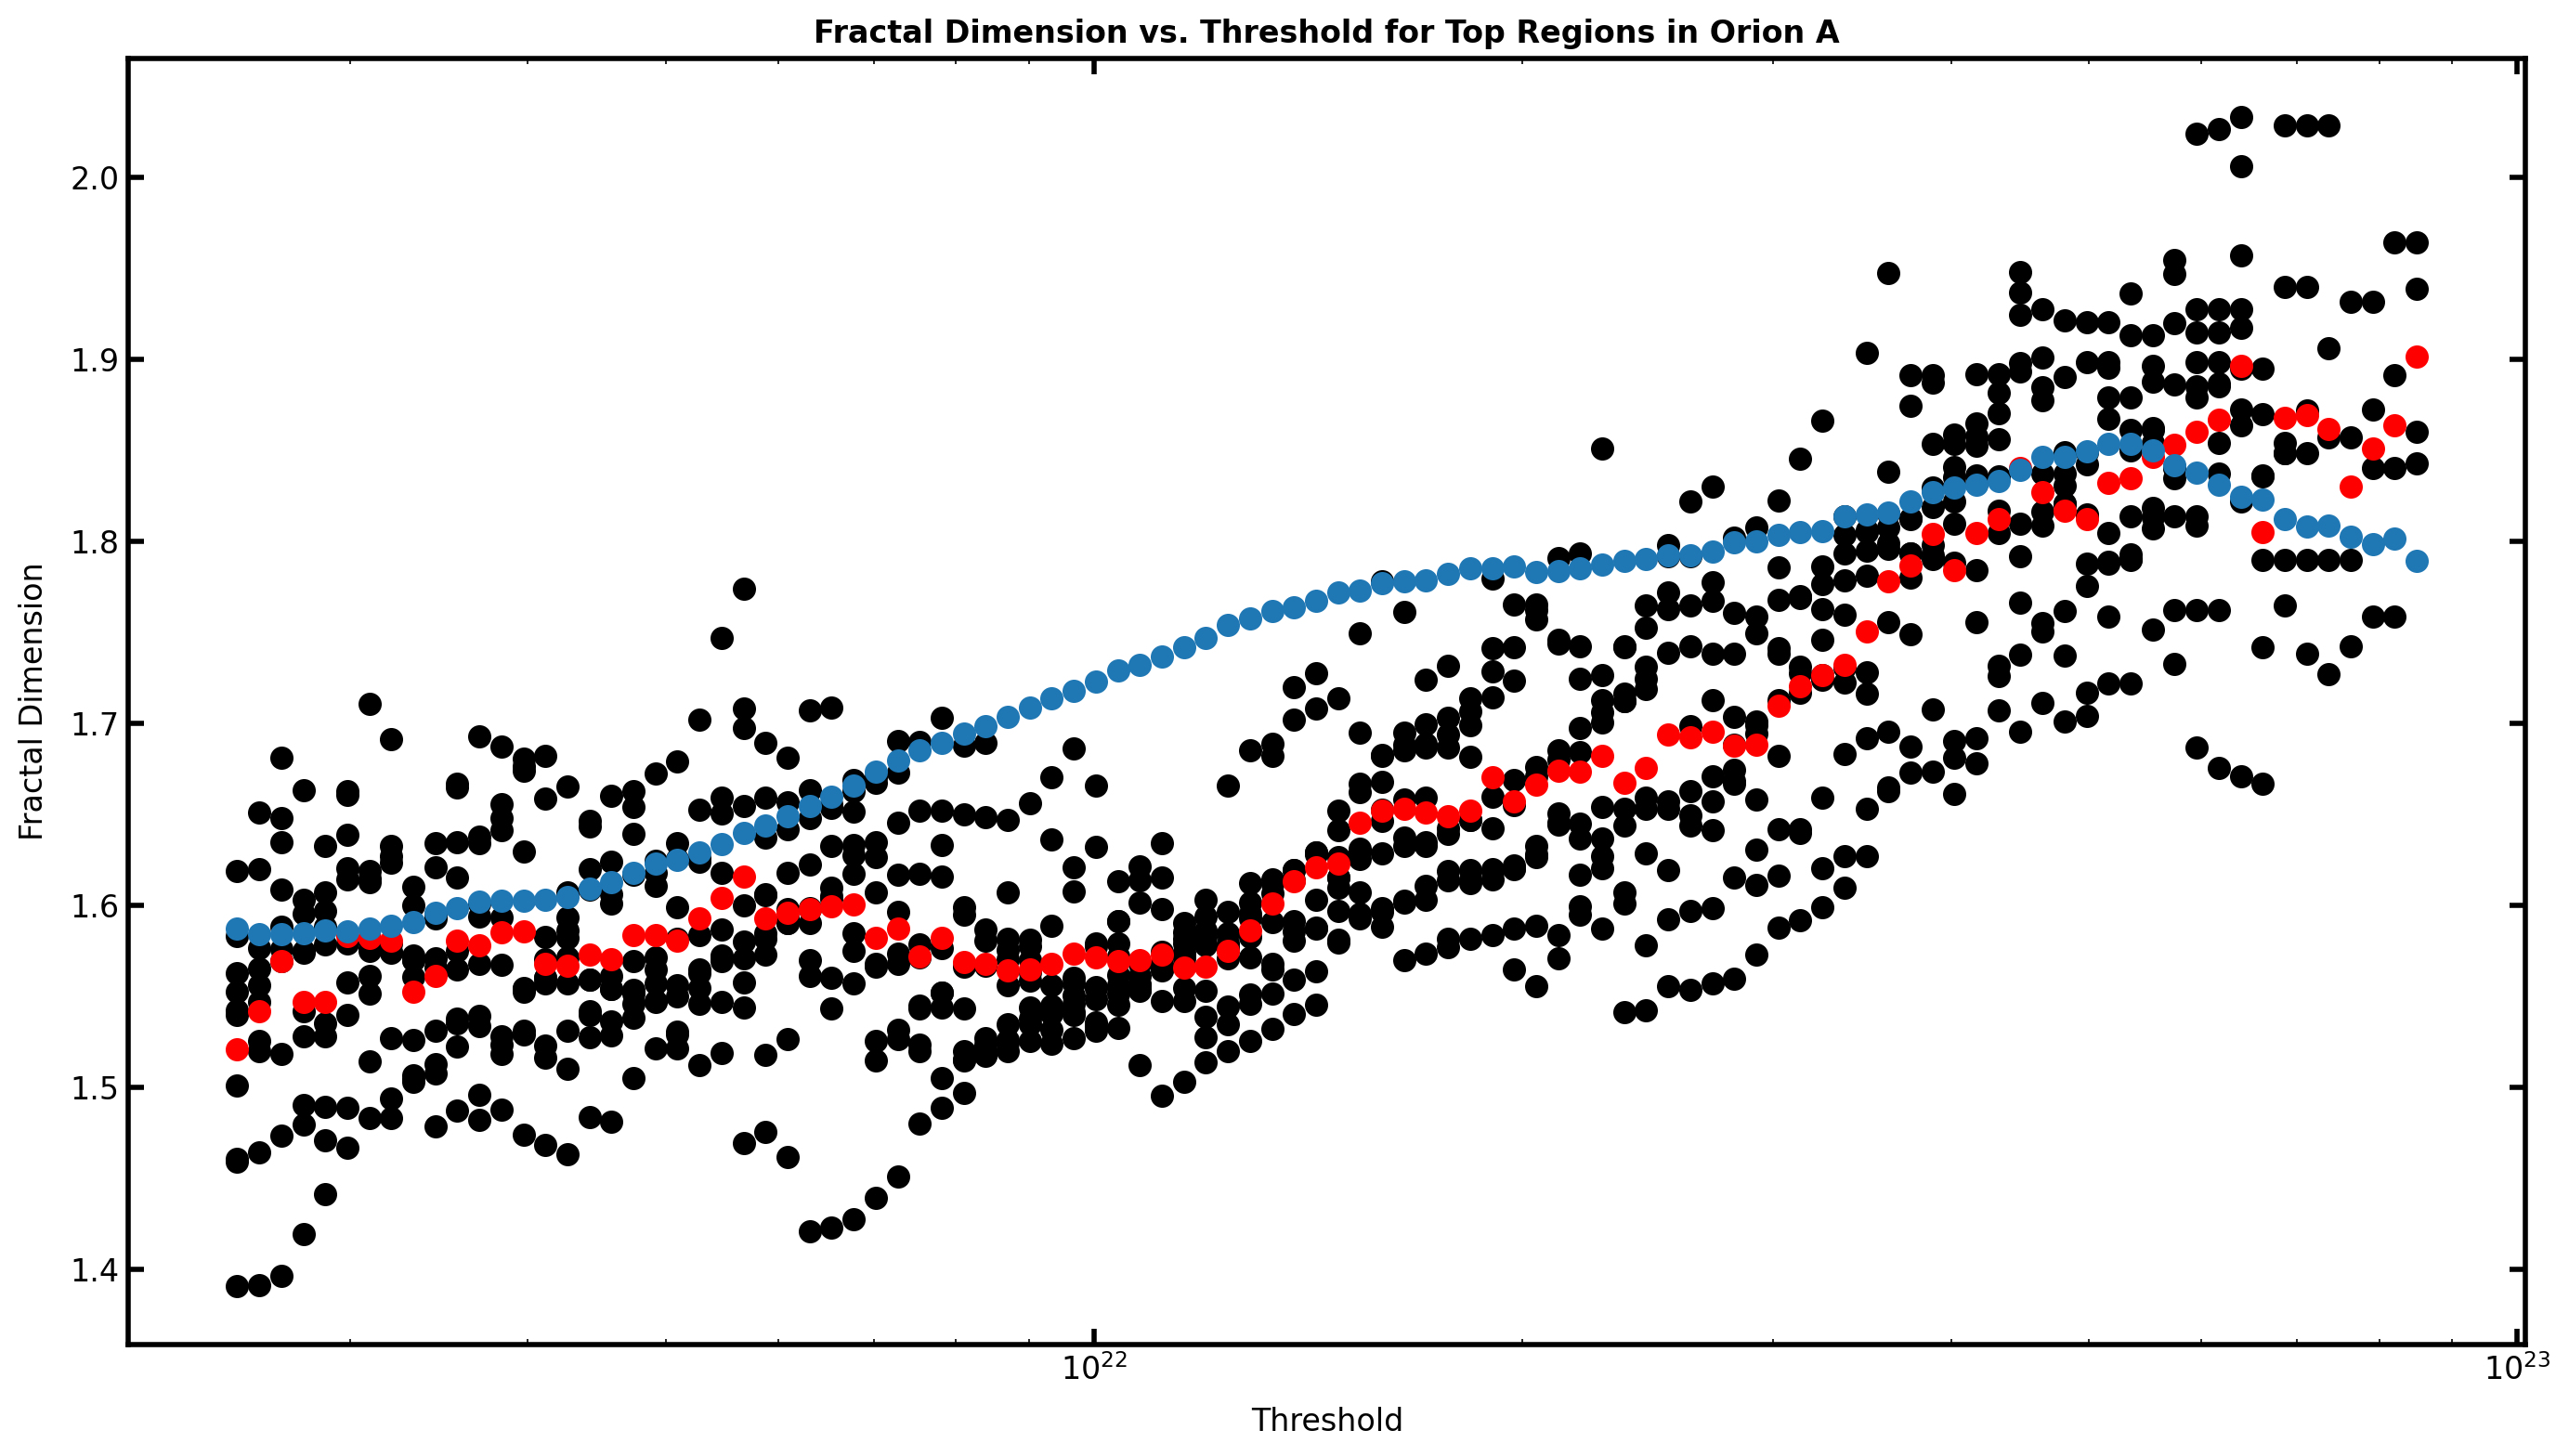

In [71]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OB = convert_to_mass(N_H2_OB)

thresholds = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100) 

if os.path.exists("top_regions_data_OA.pkl"):
    top_regions_data_OA = load_regions_from_pickle("top_regions_data_OA.pkl")
else:
    top_regions_data_OA = track_largest_regions_NEW(N_H2_OB, M_H2_OB, thresholds, pc_per_px, num_top_regions=10, min_region_size_px=8)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OA.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OA.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        label=f"Threshold: {threshold:.2e}",
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OA["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion A", fontweight='bold')
plt.show()

In [72]:
trees = find_trees_in_regions(top_regions_data_OA)
print("Found region pairs (parent, child) where child is fully contained in parent:")
for parent, child in trees:
    print(f"Parent: {parent}, Child: {child}")

Found region pairs (parent, child) where child is fully contained in parent:
Parent: 2.4999999999999995e+21_3, Child: 2.5906544706295043e+21_3
Parent: 2.4999999999999995e+21_9, Child: 2.5906544706295043e+21_7
Parent: 2.4999999999999995e+21_685, Child: 2.5906544706295043e+21_593
Parent: 2.4999999999999995e+21_47, Child: 2.5906544706295043e+21_48
Parent: 2.4999999999999995e+21_91, Child: 2.5906544706295043e+21_72
Parent: 2.4999999999999995e+21_132, Child: 2.5906544706295043e+21_111
Parent: 2.4999999999999995e+21_109, Child: 2.5906544706295043e+21_85
Parent: 2.4999999999999995e+21_583, Child: 2.5906544706295043e+21_489
Parent: 2.4999999999999995e+21_781, Child: 2.5906544706295043e+21_684
Parent: 2.4999999999999995e+21_3, Child: 2.6845962344770563e+21_3
Parent: 2.4999999999999995e+21_9, Child: 2.6845962344770563e+21_8
Parent: 2.4999999999999995e+21_685, Child: 2.6845962344770563e+21_627
Parent: 2.4999999999999995e+21_47, Child: 2.6845962344770563e+21_48
Parent: 2.4999999999999995e+21_3, Ch

1723


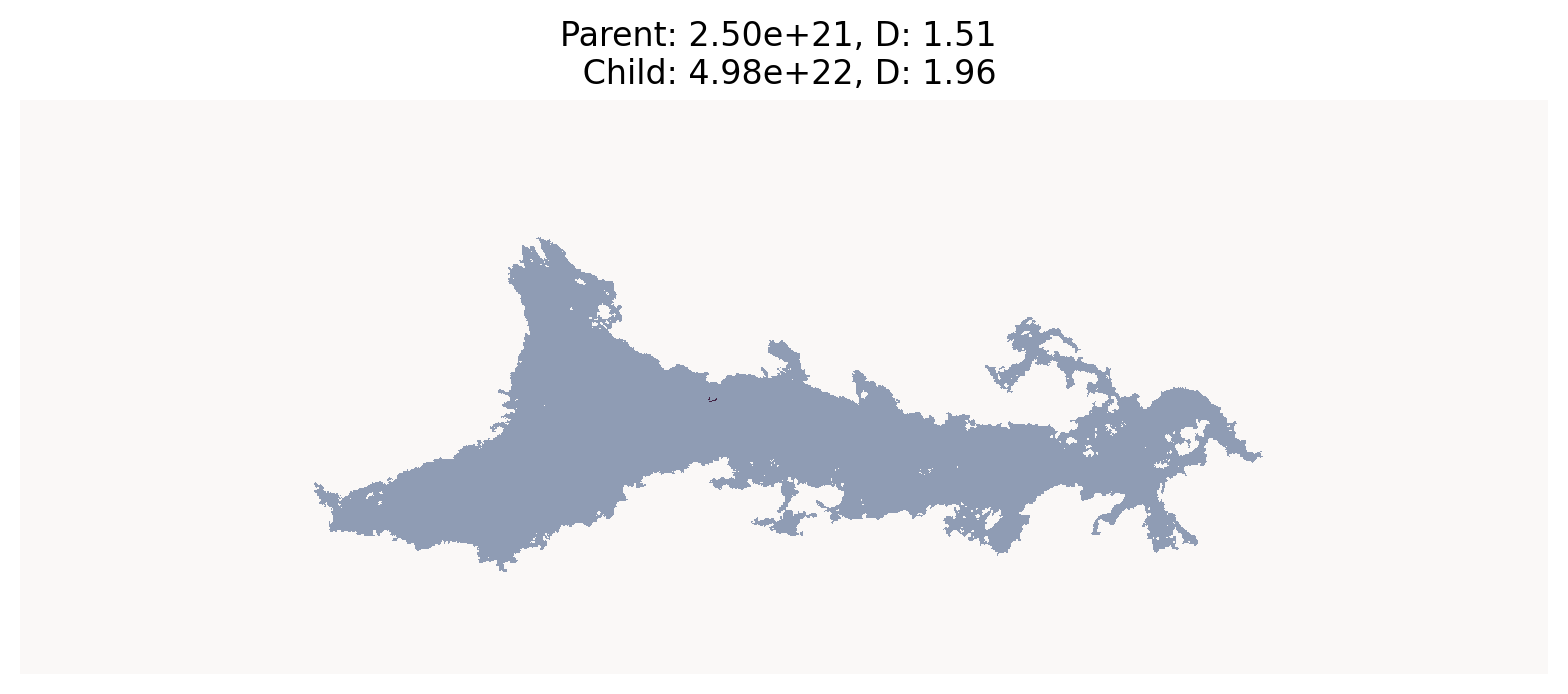

Plotted parent: 2.4999999999999995e+21_22, child: 4.98168961847443e+22_48 with max fractal_dimension: 1.9630047912470099


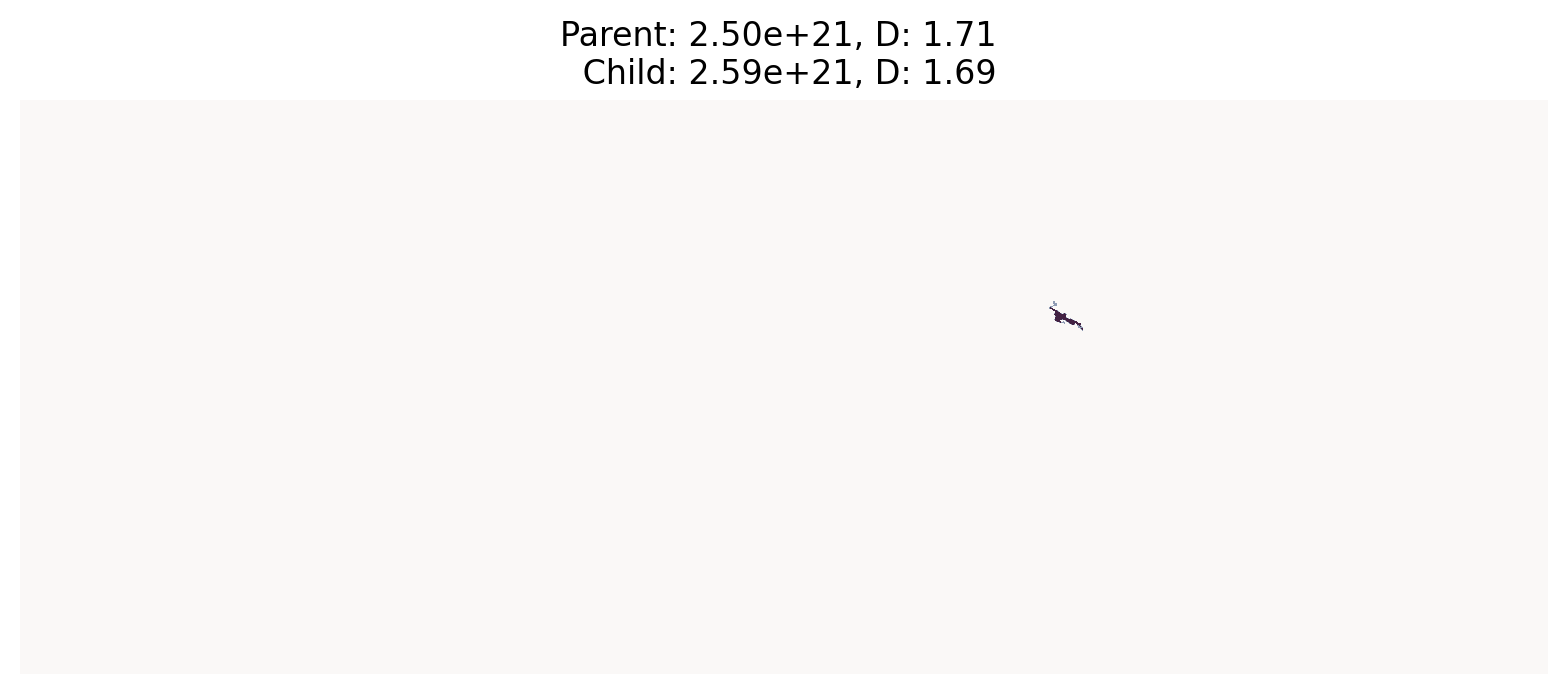

Max fractal_dimension in filtered_trees: 1.9630047912470099


In [30]:
# Plot parent and child regions with their fractal dimensions

def plot_parent_child_regions(region_dict, parent_key, child_key, ax=None):
    parent_data = region_dict[parent_key]
    child_data = region_dict[child_key]
    parent_mask = parent_data["region_mask"]
    child_mask = child_data["region_mask"]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig = None

    # Plot parent region in light blue
    ax.imshow(parent_mask, cmap='Blues', alpha=0.9, origin='lower', label='Parent')
    # Overlay child region in red
    ax.imshow(child_mask, cmap='Reds', alpha=0.5, origin='lower', label='Child')

    # Annotate fractal dimensions
    def format_key(key):
        # Extract the threshold part and format with 2 digits in scientific notation
        threshold_str = key.split('_')[0]
        threshold = float(threshold_str)
        return f"{threshold:.2e}"

    ax.set_title(
        f"Parent: {format_key(parent_key)}, D: {parent_data['fractal_dimension']:.2f} \n "
        f"Child: {format_key(child_key)}, D: {child_data['fractal_dimension']:.2f}",
        fontsize=12
    )
    ax.axis('off')

    if fig is not None:
        plt.show()

threshold_value_child = 7e22  # Set your desired threshold here
threshold_value_parent = 2.4e21 

filtered_trees = [
    (parent_key, child_key)
    for parent_key, child_key in trees
    if float(child_key.split('_')[0]) < threshold_value_child
    and float(parent_key.split('_')[0]) > threshold_value_parent
]

print(len(filtered_trees))
# Find the (parent_key, child_key) pair where the child's fractal_dimension is max_fd
for parent_key, child_key in filtered_trees:
    if np.isclose(top_regions_data_OA[child_key]['fractal_dimension'], max_fd):
        plot_parent_child_regions(top_regions_data_OA, parent_key, child_key)
        print(f"Plotted parent: {parent_key}, child: {child_key} with max fractal_dimension: {max_fd}")
        break

if filtered_trees:
    parent_key, child_key = filtered_trees[10]
    plot_parent_child_regions(top_regions_data_OA, parent_key, child_key)

    max_fd = max(
        top_regions_data_OA[child]['fractal_dimension']
        for _, child in filtered_trees
    )
    print("Max fractal_dimension in filtered_trees:", max_fd)

---

In [ ]:
# Which is the pixel size against the beam size (36")


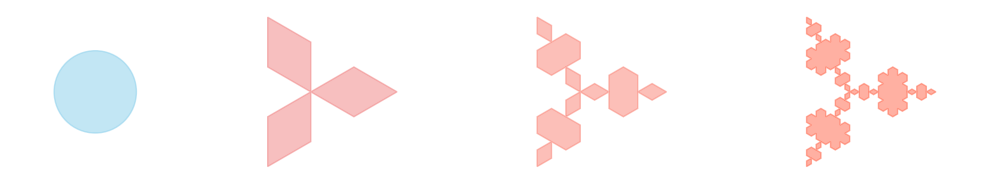

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from math import sqrt, pi

def koch_snowflake(order, scale=10):
    def _koch_snowflake_complex(order):
        """Generate Koch snowflake as complex numbers."""
        if order == 0:
            # Start with equilateral triangle
            angles = np.array([0, 2*np.pi/3, 4*np.pi/3])
            return scale * np.exp(1j * angles)
        else:
            prev = _koch_snowflake_complex(order - 1)
            new = []
            for i in range(len(prev)):
                z1 = prev[i]
                z2 = prev[(i + 1) % len(prev)]
                dz = z2 - z1
                new += [
                    z1,
                    z1 + dz / 3,
                    z1 + dz / 3 + (dz / 3) * np.exp(1j * np.pi / 3),
                    z1 + dz * 2 / 3
                ]
            return np.array(new)
    pts = _koch_snowflake_complex(order)
    pts = np.append(pts, pts[0])  # close the loop
    return np.real(pts), np.imag(pts)

# Set up plot
fig, ax = plt.subplots(figsize=(10, 15))

# Circle with same perimeter as initial triangle
triangle_side = 8
initial_perimeter = 3 * triangle_side
circle_radius = initial_perimeter / (2 * pi)
circle = plt.Circle((0, 0), circle_radius, color='skyblue', alpha=0.5, label='Circle')

# Plot circle
ax.add_patch(circle)
ax.plot([], [], color='skyblue', label='Circle (max area for given perimeter)')

# Koch snowflakes of increasing order
orders = [1, 2, 3]
colors = ['lightcoral', 'salmon', 'tomato', 'orangered']

for i, order in enumerate(orders):
    x, y = koch_snowflake(order, scale=triangle_side)
    x += 20  # shift right to avoid overlap
    ax.fill(x + i * 25, y, alpha=0.5, color=colors[i], label=f'Koch order {order}')

# Annotations and formatting
ax.set_aspect('equal')
# ax.set_title('Same Perimeter – Different Areas')
ax.axis('off')
# ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


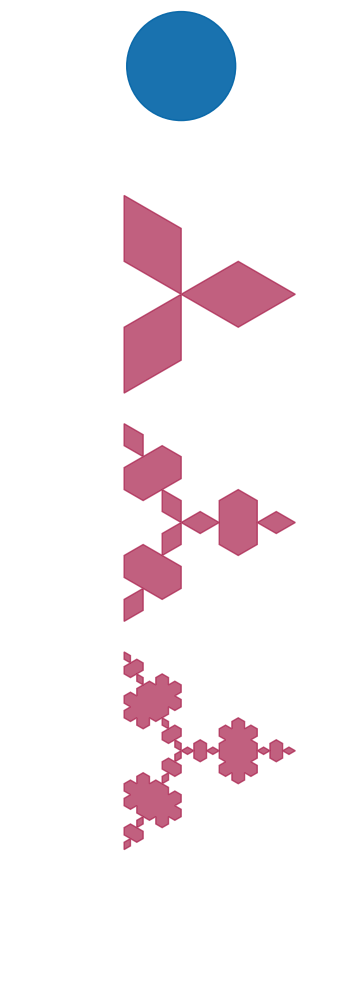

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from math import pi

def koch_snowflake(order, scale=10):
    def _koch_snowflake_complex(order):
        """Generate Koch snowflake as complex numbers."""
        if order == 0:
            angles = np.array([0, 2*np.pi/3, 4*np.pi/3])
            return scale * np.exp(1j * angles)
        else:
            prev = _koch_snowflake_complex(order - 1)
            new = []
            for i in range(len(prev)):
                z1 = prev[i]
                z2 = prev[(i + 1) % len(prev)]
                dz = z2 - z1
                new += [
                    z1,
                    z1 + dz / 3,
                    z1 + dz / 3 + (dz / 3) * np.exp(1j * np.pi / 3),
                    z1 + dz * 2 / 3
                ]
            return np.array(new)
    pts = _koch_snowflake_complex(order)
    pts = np.append(pts, pts[0])  # close the loop
    return np.real(pts), np.imag(pts)

# Set up figure
fig, ax = plt.subplots(figsize=(5, 10))  # Taller aspect for vertical stacking

# Circle parameters
triangle_side = 10
initial_perimeter = 3 * triangle_side
circle_radius = initial_perimeter / (2 * pi)

# Add circle (top)
circle = Circle((0, 80), circle_radius, color='#0063A6', alpha=0.9, label='Circle (max area)')
ax.add_patch(circle)

# Add Koch snowflakes underneath with vertical spacing
orders = [1, 2, 3]
colors = ['lightcoral', 'salmon', 'tomato', 'orangered']
vertical_spacing = 20  # Space between each shape

for i, order in enumerate(orders):
    x, y = koch_snowflake(order, scale=triangle_side)
    y_offset = 60 - i * vertical_spacing  # Stack downward
    ax.fill(x, y + y_offset, color="#A71C49", alpha=0.7, label=f'Koch order {order}')

# Final formatting
ax.set_aspect('equal')
ax.set_xlim(-15, 15)
ax.set_ylim(0, 85)
ax.axis('off')
# ax.set_title('Same Perimeter — Different Areas', fontsize=14, pad=20)
# ax.legend(loc='lower center', fontsize=9)
plt.tight_layout()
plt.show()

In [3]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Fitting
from scipy.optimize import curve_fit

# Image Analysis Specific Imports
from skimage.measure import perimeter, euler_number
from scipy.ndimage import rotate

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# GRF
from GRF import generate_gaussian_random_field

# 2D Gaussian
from Gaussian import generate_2d_gaussian

# Sierpinski Triangle
from Sierpinski_Triangle import generate_sierpinski_triangle

# Visualization Tools
# from visualization_tools import show_shapes_results, plot_


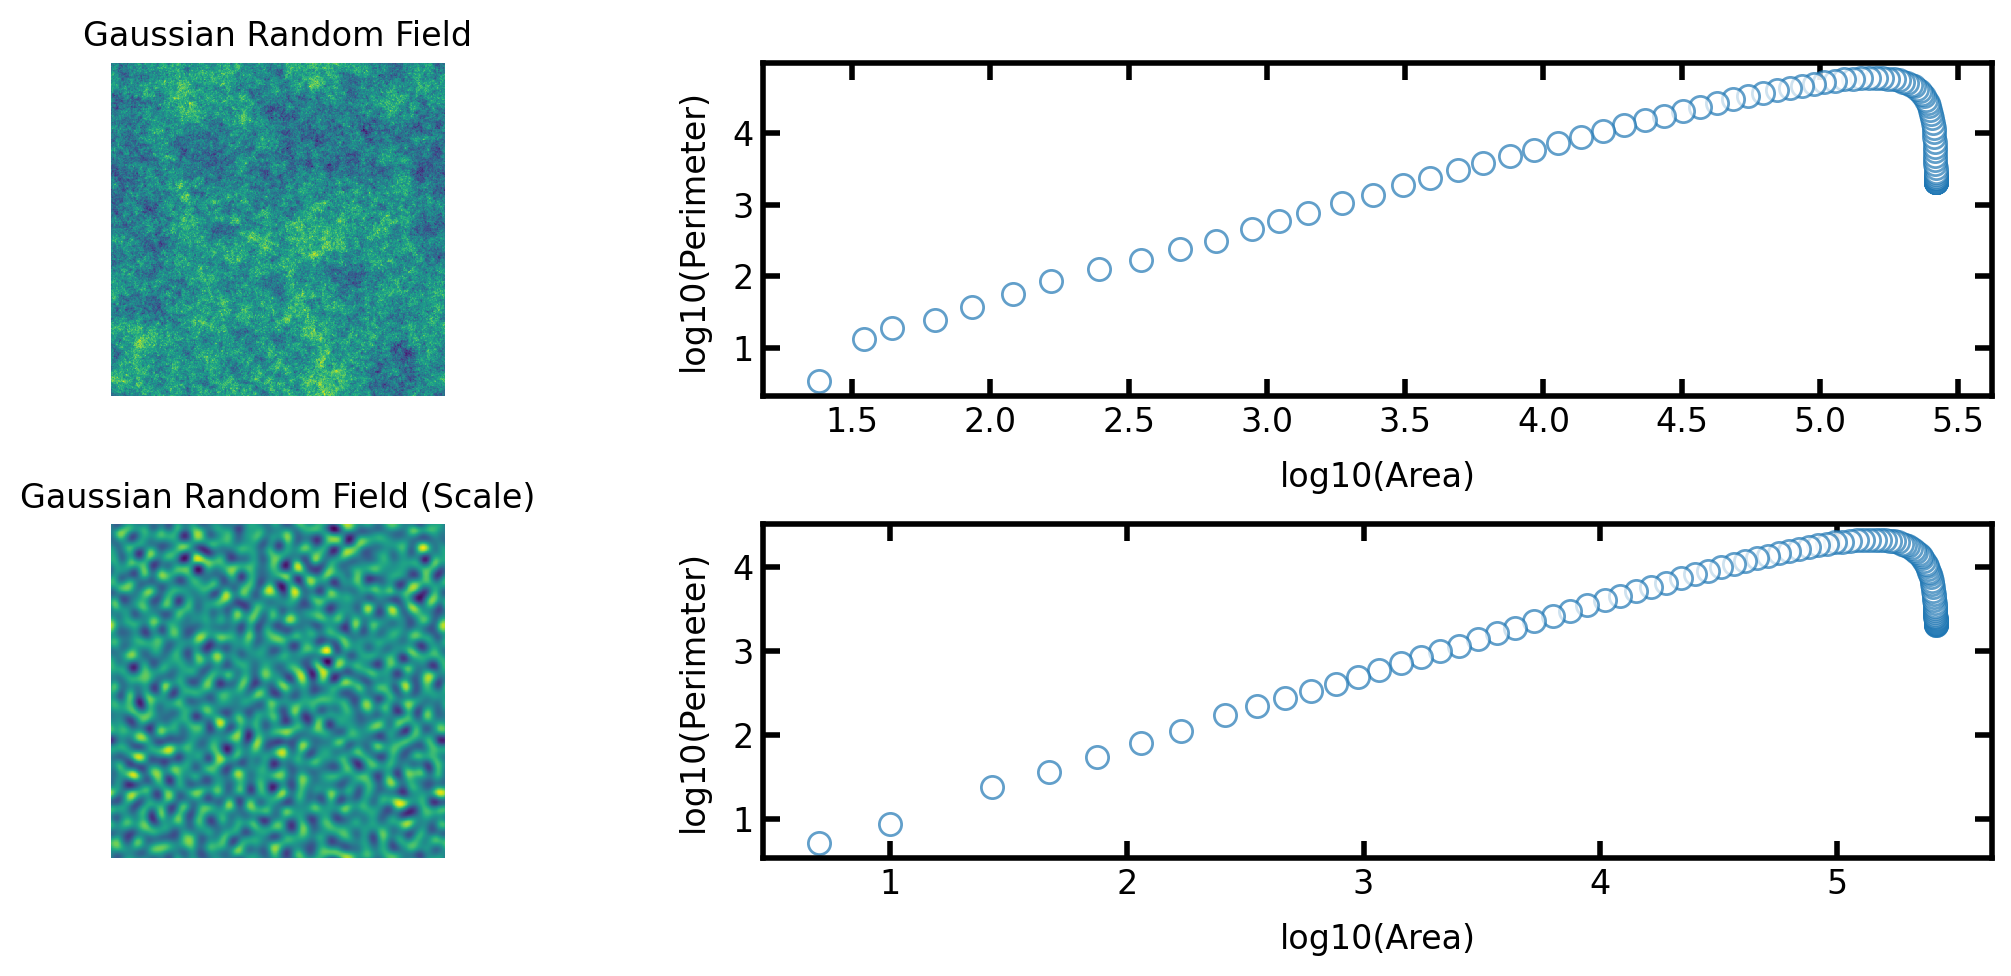

In [24]:
from skimage.measure import perimeter

GRF, GRF_scale = generate_gaussian_random_field(512, a=-2)

# Generate a GRF with a peaked power spectrum (characteristic scale)
def generate_peaked_grf(size, peak_scale=16, amplitude=1.0):
    # Create frequency grid
    kx = np.fft.fftfreq(size)
    ky = np.fft.fftfreq(size)
    kx, ky = np.meshgrid(kx, ky)
    k = np.sqrt(kx**2 + ky**2)
    # Peaked spectrum: Gaussian in k-space centered at k0 = 1/peak_scale
    k0 = 1.0 / peak_scale
    power_spectrum = amplitude * np.exp(-0.5 * ((k - k0) / (0.2 * k0))**2)
    # Random phases
    random_phases = np.exp(2j * np.pi * np.random.rand(size, size))
    # Fourier coefficients
    fourier_field = np.sqrt(power_spectrum) * random_phases
    # Inverse FFT to real space
    grf_peaked = np.fft.ifft2(fourier_field).real
    # Normalize
    grf_peaked = (grf_peaked - np.mean(grf_peaked)) / np.std(grf_peaked)
    return grf_peaked

GRF_peaked = generate_peaked_grf(512, peak_scale=32)

thresholds_GRF = np.linspace(np.min(GRF), np.max(GRF), 100)

thresholds_GRF_peaked = np.linspace(np.min(GRF_peaked), np.max(GRF_peaked), 100)

areas = []
perimeters = []

areas_2 = []
perimeters_2 = []

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
axes[0, 0].imshow(GRF, cmap='viridis')
axes[0, 0].set_title("Gaussian Random Field")
axes[0, 0].axis('off')

axes[1, 0].imshow(GRF_peaked, cmap='viridis')
axes[1, 0].set_title("Gaussian Random Field (Scale)")
axes[1, 0].axis('off')

for thresh in thresholds_GRF:
    mask = GRF > thresh
    area = np.sum(mask)
    peri = perimeter(mask)
    areas.append(area)
    perimeters.append(peri)

for thresh in thresholds_GRF_peaked:
    mask = GRF_peaked > thresh
    area_2 = np.sum(mask)
    peri_2 = perimeter(mask)
    areas_2.append(area_2)
    perimeters_2.append(peri_2)

# Remove zero areas/perimeters to avoid log(0)
areas = np.array(areas)
perimeters = np.array(perimeters)
valid = (areas > 0) & (perimeters > 0)

areas_2 = np.array(areas_2)
perimeters_2 = np.array(perimeters_2)
valid_2 = (areas_2 > 0) & (perimeters_2 > 0)

axes[0, 1].plot(np.log10(areas[valid]), np.log10(perimeters[valid]),'o', alpha=0.7)
axes[0, 1].set_xlabel('log10(Area)')
axes[0, 1].set_ylabel('log10(Perimeter)')
# axes[0, 1].set_title('log(Area) vs log(Perimeter) for GRF thresholds')

axes[1, 1].plot(np.log10(areas_2[valid_2]), np.log10(perimeters_2[valid_2]), 'o', alpha=0.7)
axes[1, 1].set_xlabel('log10(Area)')
axes[1, 1].set_ylabel('log10(Perimeter)')
# axes[1, 1].set_title('log(Area) vs log(Perimeter) for GRF thresholds')

plt.tight_layout()
plt.show()

Scale-free fit R^2: 0.7776827984698044
Peaked GRF fit R^2: 0.6802250886174492


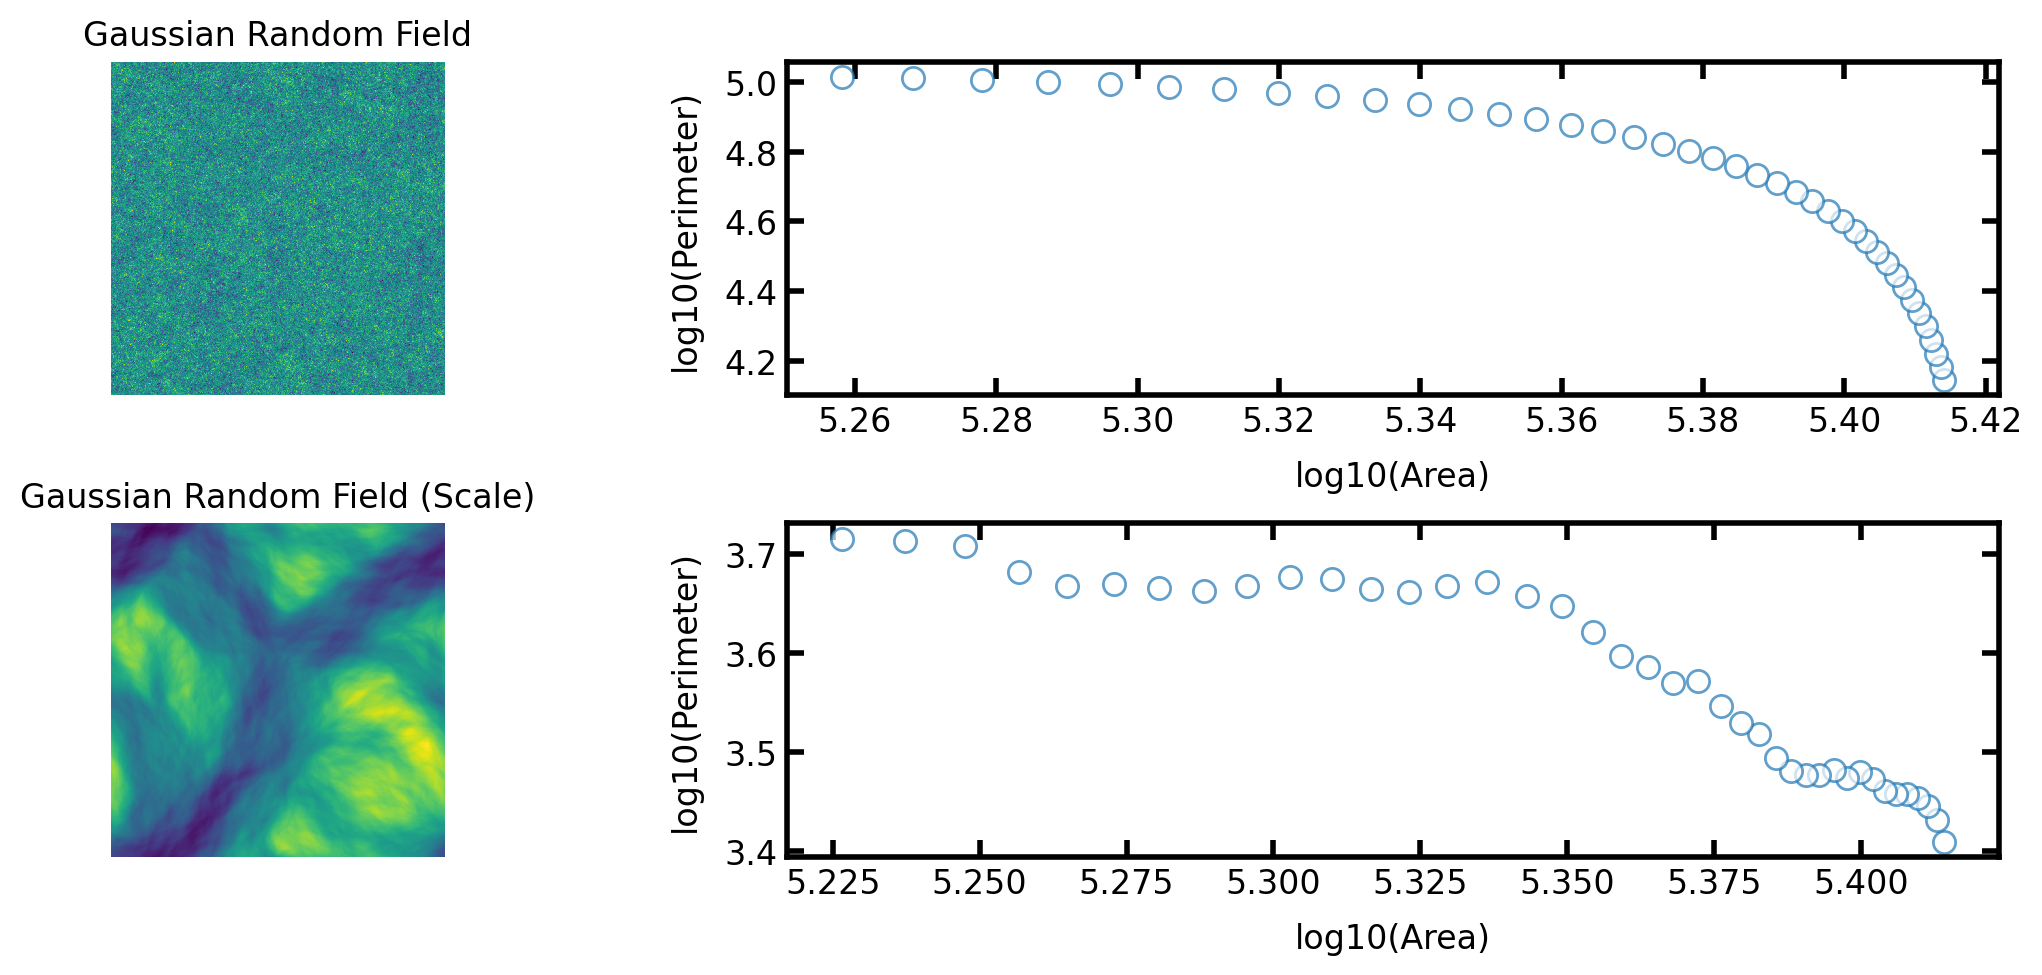

In [56]:
from skimage.measure import perimeter

GRF, _ = generate_gaussian_random_field(512, a=-1)

_, GRF_scale = generate_gaussian_random_field(512, a=-4)

# Use percentiles instead of min/max for thresholds
low_GRF, high_GRF = np.percentile(GRF, [1, 99])
thresholds_GRF = np.linspace(low_GRF, high_GRF, 100)

low_GRF_peaked, high_GRF_peaked = np.percentile(GRF_scale[:, :, 0], [1, 99])
thresholds_GRF_peaked = np.linspace(low_GRF_peaked, high_GRF_peaked, 100)

areas = []
perimeters = []

areas_2 = []
perimeters_2 = []

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
axes[0, 0].imshow(GRF, cmap='viridis')
axes[0, 0].set_title("Gaussian Random Field")
axes[0, 0].axis('off')

axes[1, 0].imshow(GRF_scale[:, :, 0], cmap='viridis')
axes[1, 0].set_title("Gaussian Random Field (Scale)")
axes[1, 0].axis('off')

for thresh in thresholds_GRF:
    mask = GRF > thresh
    area = np.sum(mask)
    peri = perimeter(mask)
    areas.append(area)
    perimeters.append(peri)

for thresh in thresholds_GRF_peaked:
    mask = GRF_scale[:, :, 0] > thresh
    area_2 = np.sum(mask)
    peri_2 = perimeter(mask)
    areas_2.append(area_2)
    perimeters_2.append(peri_2)

# Remove zero areas/perimeters to avoid log(0)
areas = np.array(areas)
perimeters = np.array(perimeters)
valid = (areas > 0) & (perimeters > 0)

areas_2 = np.array(areas_2)
perimeters_2 = np.array(perimeters_2)
valid_2 = (areas_2 > 0) & (perimeters_2 > 0)

axes[0, 1].plot(np.log10(areas[valid][:40]), np.log10(perimeters[valid][:40]),'o', alpha=0.7)
axes[0, 1].set_xlabel('log10(Area)')
axes[0, 1].set_ylabel('log10(Perimeter)')
# axes[0, 1].set_title('log(Area) vs log(Perimeter) for GRF thresholds')

axes[1, 1].plot(np.log10(areas_2[valid_2][:40]), np.log10(perimeters_2[valid_2][:40]), 'o', alpha=0.7)
axes[1, 1].set_xlabel('log10(Area)')
axes[1, 1].set_ylabel('log10(Perimeter)')
# axes[1, 1].set_title('log(Area) vs log(Perimeter) for GRF thresholds')

from scipy.stats import linregress

slope1, intercept1, r_value1, *_ = linregress(np.log10(areas[valid]), np.log10(perimeters[valid]))
slope2, intercept2, r_value2, *_ = linregress(np.log10(areas_2[valid_2]), np.log10(perimeters_2[valid_2]))

print("Scale-free fit R^2:", r_value1**2)
print("Peaked GRF fit R^2:", r_value2**2)

plt.tight_layout()
plt.show()

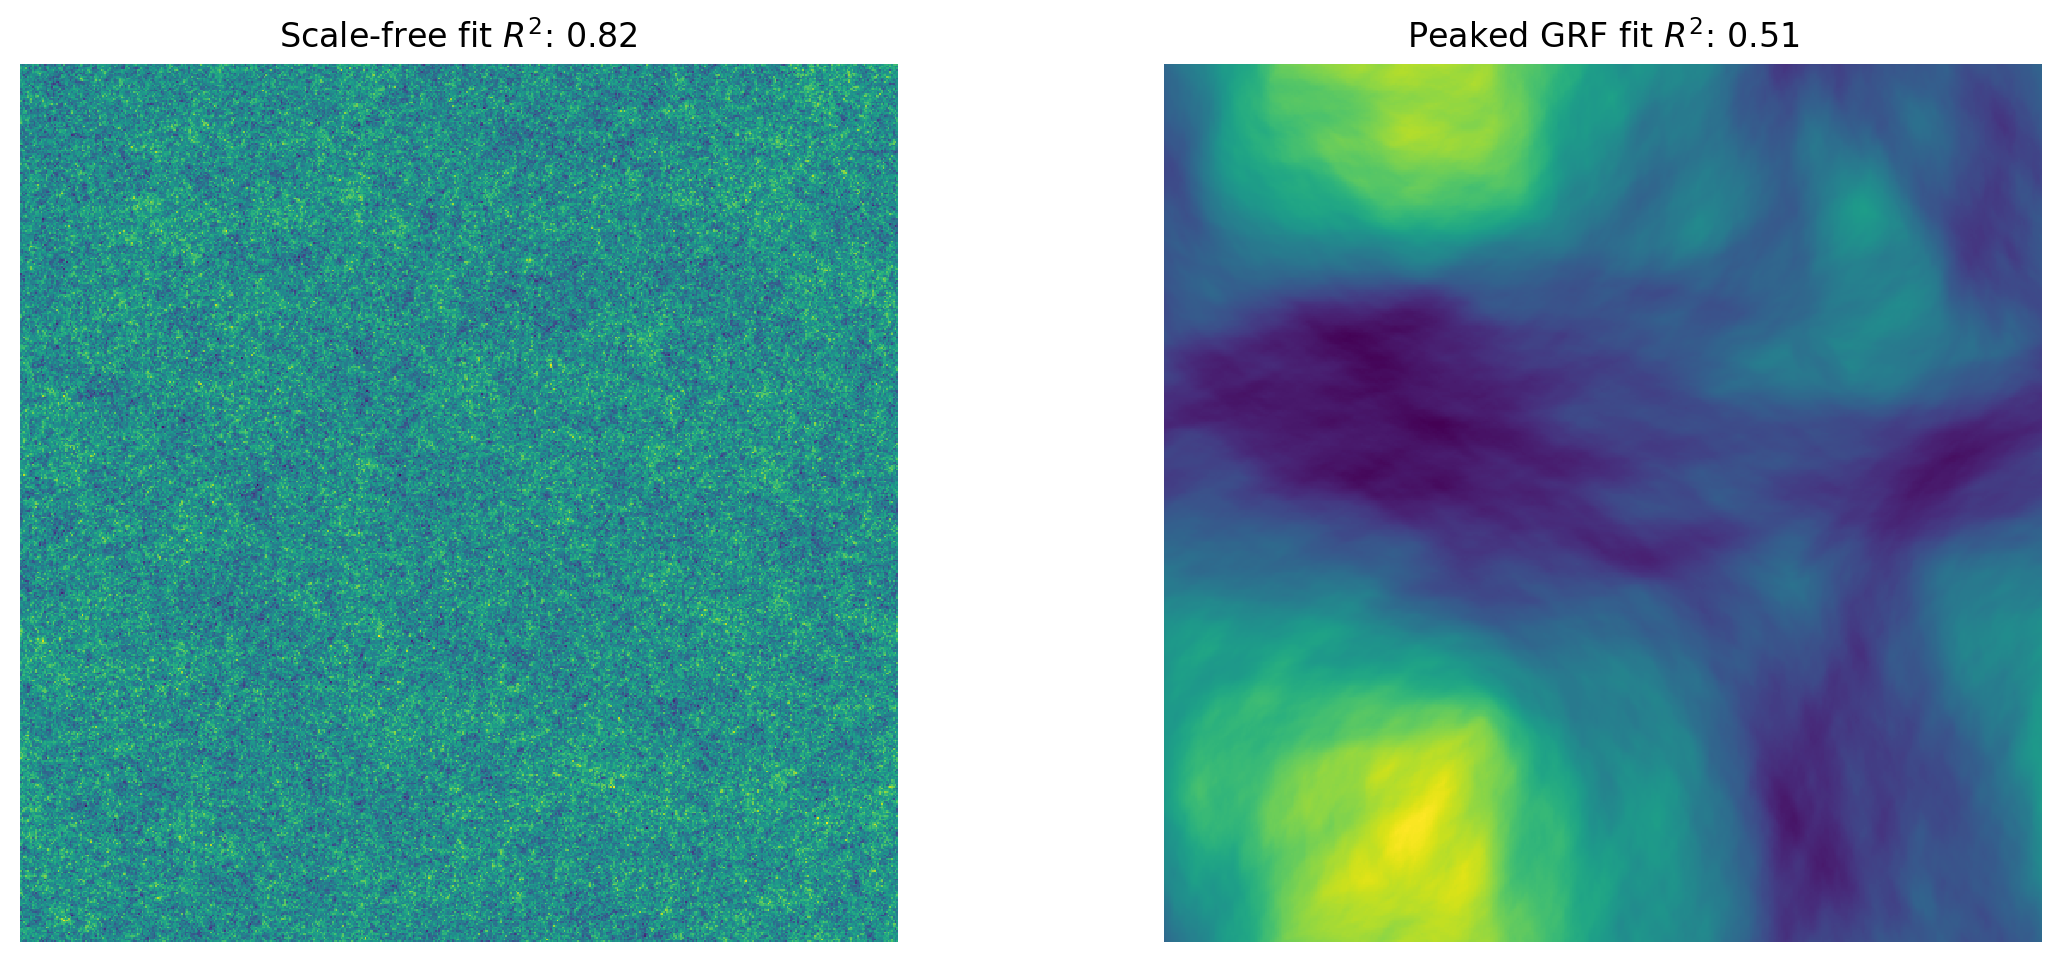

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(GRF, cmap='viridis')
axes[0].set_title("Scale-free fit $R^2$: 0.82")
axes[0].axis('off')

axes[1].imshow(GRF_scale[:, :, 0], cmap='viridis')
axes[1].set_title("Peaked GRF fit $R^2$: 0.51")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Print the superscript 2 character (Unicode)
print("²")